# Bước 06_1: Train Huber loss khử trễ pha
Dự án: Tốt nghiệp - Energy Forecasting - Nhóm thực hiện: The Outliers

## 1. TỔNG QUAN VÀ MỤC TIÊU

### Vấn đề
Mô hình cũ bị **trễ pha 30 phút**: dự báo tại `T` khớp nhất với sản lượng thật tại `T-30 phút`.
Đo trên toàn bộ 42 trạm của tập test, **cả 42 trạm** đều khớp nhất tại `k=2` (tức 2 bước = 30 phút).

Nguyên nhân đã truy được:

1. `lag_1` của hàng đặc trưng chính là `y(T-30 phút)`, và nó tương quan 99% với mục tiêu.
   Mô hình tối thiểu hoá sai số trung bình nên **chép** cột đó thay vì học quan hệ vật lý.
2. Dữ liệu thời tiết là **theo giờ, bị lặp 4 lần** trên lưới 15 phút. Trong một giờ nó không phân biệt
   được `12:00` với `12:15`, nên `lag_1` là nguồn tín hiệu 15 phút duy nhất mà mô hình có.
   Bỏ riêng `lag_1` mà không bù gì thì WAPE tụt thảm vì mất luôn nguồn thông tin đó.

### Cách khử, năm việc làm cùng lúc
| việc | mục đích |
|---|---|
| Downscale bức xạ về 15 phút bằng bức xạ trời quang | tạo tín hiệu 15 phút thay cho `lag_1` |
| Góc cao và góc phương vị mặt trời | cho mô hình biết vị trí mặt trời tại trạm, phân giải 15 phút |
| Quy mô trạm thực nghiệm | `capacity_kw` sai ở nhiều trạm, phải tính lại từ dữ liệu train |
| Trần công suất trạm | học được đoạn inverter cắt đỉnh, chỗ sản lượng nằm phẳng |
| Bỏ `lag_1`, `lag_4`, `rolling_*_4`, `rolling_*_12` | cắt đường tắt mang giá trị `T-30 phút` |

**Vẫn giữ `lag_96` và `rolling_*_96`** - lịch sử một ngày trước, nên đây vẫn là mô hình time series
có ký ức, chỉ bỏ phần mang sẵn đáp án.

### Kết quả đã đạt
| | mô hình cũ | mô hình này |
|---|---|---|
| số trạm khớp nhất tại `k=0` | 0/42 | **40/42** |
| RMSE `k=0` so với `k=1` | k=2 nhỏ nhất | **k=0 nhỏ nhất** |
| WAPE | 24,69% | 21,09% |

### Điều quan trọng về tính nhân quả
Toàn bộ đặc trưng mới **chỉ dùng thông tin quá khứ và công thức thiên văn**. Không nội suy giữa các giờ,
không dùng giá trị của giờ sau. Phần biến thiên trong giờ do bức xạ trời quang tạo ra, mà bức xạ trời quang
là hàm xác định của thời điểm và toạ độ.


## 2. Import thư viện và khai báo tham số


In [1]:
# ── Gioi han thread: may i5-12450HX co 8 core / 12 thread (4 P-core + 4 E-core).
# Dung het 12 thread lam cac thread tranh nhau va CHAM HON. Dat 6 de bam P-core,
# con lai de cho Jupyter va he dieu hanh. Phai set TRUOC khi numpy nap moi co tac dung.
import os

for _bien in ('OMP_NUM_THREADS', 'OPENBLAS_NUM_THREADS','MKL_NUM_THREADS',
              'NUMEXPR_NUM_THREADS', 'VECLIB_MAXIMUM_THREADS'):
    os.environ.setdefault(_bien, '6')

import gc
import json
import os
import pickle
import platform
import time
import warnings

import lightgbm as lgb
from lightgbm import LGBMRegressor, early_stopping, log_evaluation
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
import pyarrow.parquet as pq
import seaborn as sns
from optuna.samplers import TPESampler
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")
optuna.logging.set_verbosity(optuna.logging.WARNING)

# ── Cột khoá ──
VERSION = 'v4'
SITE_COL = 'site_id'
TIMESTAMP_COL = 'timestamp'
TARGET_COL = 'energy_generated_kwh'

# ── Tham số mô hình ──
# Bien the LOSS = MSE, doi chieu voi 06_1 (mae, dang chon lam mac dinh bao cao) va
# 06_2 (huber). MSE phat rat nang sai so lon (binh phuong) nen nhay voi outlier/dinh
# hon MAE va Huber - dung de xem model co bi keo lech boi vai diem dinh cao hay khong.
# Ket qua so sanh thuc te MAE vs Huber tren tap test (xem 06_1_train_mae.ipynb):
#   huber a=1  : khop dinh 15p 19,9% | bien do dinh 0,916 | WAPE 21,58%
#   MAE  (l1)  : khop dinh 15p 20,1% | bien do dinh 0,952 | WAPE 21,69%   <- notebook 06_1 chon
# Notebook nay giu de doi chieu/ablation, KHONG dung lam ket qua bao cao chinh.
LOSS_NAME = 'mse'
LGB_OBJECTIVE = 'mse'
# HORIZON_STEPS: xem cell rieng ngay ben duoi (de doi h1/h4 khong can dong lai o day)
N_TRIALS = 20                  # ngan sach Optuna cho moi loss va horizon
SEED = 42
N_STARTUP_TRIALS = 5            # 5 random + 10 TPE dinh huong trong ngan sach 15 trial
MAX_ESTIMATORS_CV = 3000         # tran cao; early stopping trong tung fold quyet dinh so cay
EARLY_STOPPING_ROUNDS = 100

# ── Gioi han theo cau hinh may (i5-12450HX: 8 core / 12 thread, RAM 27 GB, RTX 3050 6 GB) ──
# CPU nay la hybrid 4 P-core + 4 E-core. Dat n_jobs = 12 lam cac thread tranh nhau va CHAM HON.
# Dung 6 thread: bam vao P-core, con lai de cho Jupyter va he dieu hanh.
N_JOBS = 6
MAX_BIN = 127                  # giam tu 255 xuong 127: bot RAM, nhanh hon, gan nhu khong mat do chinh xac
FORCE_COL_WISE = True          # tranh chi phi tu do multi-threading cua LightGBM moi lan fit
DTYPE = 'float32'              # nua bo nho so voi float64

# ── Chinh sach outlier, lay dung tu srcs/05_machine_learning/Forcasting_v3 ──
# srcs khong xoa dong outlier ma dat SAMPLE WEIGHT = 0, va xet nhom cua DONG NHAN y(T+h)
# chu khong phai dong dac trung. Xem build_sample_weight trong 08_train_baselines.py
# va config/05_machine_learning/forecasting_v3_final_cleaned.yaml: active_experiment
EXPERIMENT = 'measured_only_headline'
# cac gia tri hop le:
#   measured_only_headline   : measured + normal/gmm/other/multiple = 1, etl_imputed = 0
#   measured_plus_etl_imputed: nhu tren, them etl_imputed + normal = 1
#   zero_weight_gmm_consensus: bo gmm_if_consensus ra khoi train
#   zero_weight_all_flagged  : bo moi nhom bi gan co ra khoi train
#   tran_theo_du_lieu        : nhu measured_only_headline, NHUNG chi loai dong that su vuot
#                              tran_cong_suat tinh tu DU LIEU, thay vi tin co physical_over_capacity
#                              (co nay suy tu capacity_kw metadata dang SAI o 11/42 tram)
# THU NGHIEM 1 (DA HUY, 2026-07-31) - tung doi mac dinh sang 'tran_theo_du_lieu' vi
#   capacity_kw metadata sai o 11/42 tram (vd site 19 vuot tran metadata 4,89 lan) nen
#   physical_over_capacity dang loai oan du lieu that. NHUNG: kiem tra lai phat hien
#   tran_cong_suat (trinh suy tu du lieu) cung co the bi lech neu du lieu dau vao da
#   nhiem gia tri impute sai gan tran (vd site 19 co dong etl_imputed = 43,08 kWh lap lai,
#   gan tran metadata, khong phai do that) -> dieu kien vuot_tran_that khong loai duoc
#   cac dong nay, model van hoc theo. QUAY VE 'measured_only_headline': zero-weight
#   TOAN BO physical_over_capacity vo dieu kien (dung nhu srcs/05 goc), de dam bao khi
#   plot actual-vs-predict co the CHUNG MINH model khong hoc theo outlier.

# THU NGHIEM 2 - trong so vung dinh, chua sai biet bien do ~6-12% tren ca 42 site.
# Nhan trong so voi (1 + HE_SO_TRONG_SO_DINH * k) de ep model hoc ky vung san luong cao.
# Dat 0.0 de tat han thu nghiem nay.
HE_SO_TRONG_SO_DINH = 1.0   # thu 0.0/1.0/2.0: 1.0 can bang WAPE va bien do dinh tot nhat

# THU NGHIEM 3 - KHU LAG BANG CACH DICH DAC TRUNG TAT DINH SANG THOI DIEM MUC TIEU.
# Van de: y_true la san luong tai T+h, nhung sin_elevation/ghi_cs/hour... van la gia tri tai T.
# Model dung vi tri mat troi luc T de dung lai san luong luc T+h -> duong du bao chinh la
# duong mat troi bi TRE h buoc. Do cung la mau so chuan hoa (site_scale * sin_elevation(T)).
# Dich cac cot nay sang T+h KHONG phai leakage: vi tri mat troi va nhan thoi gian tai T+h la
# tinh toan thien van/lich thuan tuy, dung o T da biet chinh xac. Khac han thoi tiet (phai do).
# Thoi tiet, lag_96, rolling_* GIU NGUYEN tai T de dam bao causal.
THEM_DAC_TRUNG_MUC_TIEU = True
# Thu nghiem truoc (bac bo) chay tren du lieu CHUA hotfix join causal, luc do do tre
# chi 1 buoc. Sau hotfix (2026-07-30 21:49), cong 10.2 do lai ra shortwave_radiation
# tre 2 buoc (30 phut), sin_elevation tre 1 buoc - tinh huong khac han, phai thu lai
# tren nen du lieu moi, khong dung ket luan cu.
# Them ban tai T+h thanh cot MOI (hau to _mt), GIU NGUYEN ban tai T.
# Vi sao them chu khong thay the: da thu THAY THE va BAC BO bang so lieu that
# (duong bao y_hat = site_scale * sin_elevation, do bang MAE tren tap development):
#     toan bo     : tai T 3,1873  |  tai T+h 3,1884   -> gan nhu y nhau
#     sang 06-09h : tai T 1,5934  |  tai T+h 2,1833   -> TE HON 37%
#     chieu 16-18h: tai T 3,4002  |  tai T+h 2,8574   -> TOT HON 16%
# Ly do: buoi sang san luong that VON di sau mat troi (pin con lanh/am, inverter khoi dong),
# nen gia tri tai T khop hon; buoi chieu thi nguoc lai. Giu ca hai de model tu chon theo gio.
#
# Day la cach HOP PHAP duy nhat de bu lai do tre cai san: vi tri mat troi va nhan thoi gian
# tai T+h la tinh toan thien van/lich thuan tuy, dung o T da biet chinh xac -> KHONG leakage.
# Khac han thoi tiet: phai do moi biet, nen bat buoc giu o T.
COT_TAT_DINH = [
    # hinh hoc mat troi va dai luong suy ra tu no
    'solar_elevation', 'solar_azimuth', 'azimuth_sin', 'azimuth_cos', 'sin_elevation',
    'ghi_cs', 'clearsky_proxy', 'ky_vong', 'ty_le_bao_hoa',
    # nhan thoi gian theo lich
    'minute_of_day', 'hour_of_day', 'hour_bucket_model', 'hour', 'hour_sin', 'hour_cos',
    'minute', 'day', 'day_of_week', 'month', 'day_of_year', 'doy_sin', 'doy_cos',
]
# KHONG dich: shortwave_radiation, diffuse_solar_radiation, direct_normal_irradiance,
# temperature_c, diffuse_ratio, temp_x_shortwave, cloud_x_shortwave, rad_x_sinelev
# (co chua thoi tiet), lag_96, rolling_*_96 (lich su san luong).

# ── Tham số khử trễ pha ──
# ── CONG TAC MAU SO CHUAN HOA MUC TIEU ──────────────────────────────────────────
# 'lonij'      : dung DUNG cong thuc cua Lonij et al. (2012), phuong trinh (18) trong
#                Engerer & Mills (2014) Solar Energy 105:679-693. Mau so la phan vi 80
#                cua san luong do duoc tai CUNG KHUNG GIO, tinh tren 15 ngay LIEN TRUOC.
#                Cot pv_clr_lonij duoc sinh o notebook 03-1. PDF: reports/references/.
# 'site_scale' : cong thuc cu cua du an, site_scale (phan vi 99 toan tap) x sin(goc cao).
#                KHONG co trong bai bao nao - phan vi 99 va phep nhan sin la tu dat.
# Xem docs/2026_08_13_Nguon_Goc_Cong_Thuc_Chuan_Hoa_Muc_Tieu.md
MAU_SO = 'site_scale'
# CHON BANG THUC NGHIEM DOI DAU (2026-08-13), khong phai chon theo cam tinh.
# Cung dac trung, cung sieu tham so, CUNG TAP DONG (615.288 train / 301.634 val - giao cua
# hai mau so de so cong bang), LightGBM MAE, tam du bao 15 phut:
#     'lonij'      (dung cong thuc Lonij et al. 2012)  -> WAPE 24,8740%  (nguong cat 2,4202)
#     'site_scale' (bien the cua du an)                -> WAPE 21,9157%  (nguong cat 1,3850)
# Bien the cua du an TOT HON 2,96 diem, va tot hon o CA 13/13 khung gio. Chenh lon nhat dung
# o ria ngay: 07:00 hon 9,55 diem, 17:00 hon 5,96, 06:00 hon 5,64.
# Ly do: mau so cua Lonij cung la SO DO nen luc binh minh/hoang hon no nho va nhieu, ty so
# bung ra. Mau so cua du an dung sin(goc cao Mat Troi) - dai luong thien van biet chinh xac -
# nen on dinh o moi gio. Doi chieu them: hai mau so tuong quan 0,9797 voi nhau.
# Hinh: data/model/v4/05_selected/hinh/so_sanh_mau_so_chuan_hoa.png
# Chi tiet trich dan: docs/2026_08_13_Nguon_Goc_Cong_Thuc_Chuan_Hoa_Muc_Tieu.md

# Nguong cat muc tieu chuan hoa. De None thi SUY TU DU LIEU: lay phan vi CLIP_PHAN_VI
# cua k tren tap TRAIN. Truoc day dat cung 1.5 ma khong co xuat xu.
CLIP_K = None
CLIP_PHAN_VI = 0.99
# CHON BANG THUC NGHIEM (2026-08-13), khong tu dat. Quet muc phan vi tren tap kiem dinh,
# 276.377 dong do that ban ngay, cung dac trung va sieu tham so:
#     phan vi 90   -> nguong 1,1475 | chan 10,0%  | WAPE 22,4800%
#     phan vi 95   -> nguong 1,2252 | chan  5,0%  | WAPE 21,9856%
#     phan vi 97,5 -> nguong 1,2954 | chan  2,5%  | WAPE 21,8644%
#     phan vi 99   -> nguong 1,3813 | chan  1,0%  | WAPE 21,8714%
#     phan vi 99,5 -> nguong 1,4574 | chan  0,5%  | WAPE 21,8357%
#     phan vi 99,9 -> nguong 1,7353 | chan  0,1%  | WAPE 21,7467%   <== TOI UU
#     khong cat    -> nguong 7,4226 | chan  0,0%  | WAPE 21,7870%
# Doc ket qua: vung 97,5-100 chenh nhau chi 0,12 diem, duoi 95 thi xau di ro. Dang chu y la
# KHONG CAT lai te hon cat o 99,9 -> viec cat co ich that, khong phai lam cho dep.
# Doi chieu tai lieu: Engerer & Mills (2014) khong quy dinh gia tri cat nao, nhung moi bieu do
# cua ho ve truc K_PV trong khoang [0; 1,2] va ho goi vung tren 1 la bat thuong do may rai rac.
# Phan vi 95 tren du lieu du an cho nguong 1,2252 - gan trung mo ta do.
# Hinh: data/model/v4/05_selected/hinh/quet_muc_phan_vi_nguong_cat.png
# So lieu: data/model/v4/05_selected/quet_muc_phan_vi_nguong_cat.csv
# VI SAO CHON 0,99 CHU KHONG PHAI 0,999 (toi uu do duoc): day la lua chon THIEN VE AN TOAN,
# co chu dich, khong phai bo sot. Ly do:
#   - Chenh lech giua hai muc chi 0,125 diem WAPE (21,8714% so voi 21,7467%), rat nho.
#   - Muc 0,999 chi chan 0,1% quan sat, tuc gan nhu khong chan gi; nguong 1,7353 de lot cac
#     gia tri cuc doan ma mau so tham chieu da mat tin cay o goc cao Mat Troi thap.
#   - Muc 0,99 cho nguong 1,3813, nam gan khoang [0; 1,2] ma Engerer & Mills (2014) ve truc
#     cho chi so troi quang, va sat vung ho goi la bat thuong (tren 1).
#   - Doi lay 0,125 diem sai so de co mot rao chan chac chan hon truoc gia tri cuc doan la
#     danh doi hop ly cho mot he thong se chay that.
# Toan bo bang quet van duoc bao cao day du, khong giau muc toi uu.

EPS_ELEV = 0.05                # nguong sin(goc cao) coi la ban ngay
TZ_HE = 11.0                   # gio mua he Uc (thang 10..3)
TZ_DONG = 10.0                 # gio mua dong Uc (thang 4..9)
BO_PREFIX_NGAN = ('lag_1', 'lag_4')          # lag ngan mang gia tri T-30 phut

# ── Đường dẫn ──
# Cac dac trung dien mat troi (goc mat troi, buc xa downscale, quy mo tram) da duoc sinh
# o notebook 03-2 va di qua 04, 05. Notebook nay chi doc va train, khong tu dung dac trung.
SELECTED_DIR = '../../data/model/v4/05_selected'
# OUTPUT_DIR: xem cell rieng ngay ben duoi (phu thuoc HORIZON_STEPS)

# ── Thiết bị train và tính tái lập ──
# USE_GPU = False la CO CHU DICH, khong phai quen bat. DETERMINISTIC la co che DUY NHAT
# cua LightGBM cho ra model giong het nhau moi lan chay, va tai lieu Parameters.rst ghi ro
# no "Used only with cpu device type" - nghia la phai TAT GPU thi no moi co tac dung.
#
# DO THUC TE 2026-08-08 (huber h1, 887.980 dong x 54 dac trung, train 3 lan lien tiep,
# cung may cung seed - xem srcs/05_machine_learning/pipeline/checks/do_tinh_tai_lap_s08.py):
#   GPU (deterministic bi bo qua) : 3 lan ra 3 model KHAC nhau, lech toi 7,485e-02  | 24 giay
#   CPU, DETERMINISTIC = False    : 2 lan ra 2 model KHAC nhau, lech 2,220e-16      | 30 giay
#   CPU, DETERMINISTIC = True     : 3 lan ra 3 model GIONG HET,  lech 0             | 31 giay
#
# Gia phai tra: 7 giay moi model. Doi lai: bao cao chay lai luc nao cung ra dung con so do.
USE_GPU = False
DETERMINISTIC = True
GPU_PLATFORM_ID = 0
GPU_DEVICE_ID = 0

print("Đã import thư viện và khai báo tham số.")
print(f"- Loss              : {LOSS_NAME}")
print(f"- Số trial Optuna   : {N_TRIALS}")
print(f"- Số thread         : {N_JOBS} trên 12 thread (CPU hybrid nên không dùng hết)")
print(f"- max_bin           : {MAX_BIN}")
# Horizon va Thu muc xuat: in o cell rieng ngay ben duoi (phu thuoc HORIZON_STEPS)


Đã import thư viện và khai báo tham số.
- Loss              : mse
- Số trial Optuna   : 20
- Số thread         : 6 trên 12 thread (CPU hybrid nên không dùng hết)
- max_bin           : 127


In [2]:
# ── CHON HORIZON: h1 hay h4 (1 cell rieng, khong dinh vao cell config chinh) ──
# De train h4 sau nay: chi doi HORIZON_STEPS o day roi Restart & Run All TU CELL NAY tro
# xuong (khong can chay lai tu dau notebook, vi du lieu 05_selected da co san cho ca 2
# horizon - y_true duoc tinh runtime trong ham them_muc_tieu() qua shift(-h)).
# h1 = du bao T+15 phut (1 buoc), h4 = du bao T+60 phut/1 gio (4 buoc).
# OUTPUT_DIR tach rieng theo horizon de KHONG ghi de len ket qua h1 khi chay h4.
HORIZON_STEPS = 1              # <-- DOI DONG NAY THANH 4 DE TRAIN H4

OUTPUT_DIR = (
    '../../data/model/v4/06_3_train_mse' if HORIZON_STEPS == 1
    else f'../../data/model/v4/06_3_train_mse_h{HORIZON_STEPS}'
)
os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"Horizon dang chon: h{HORIZON_STEPS} ({HORIZON_STEPS * 15} phut)")
print(f"Ghi ket qua vao: {OUTPUT_DIR}")


Horizon dang chon: h1 (15 phut)
Ghi ket qua vao: ../../data/model/v4/06_3_train_mse


## 3. Thiết lập GPU (OpenCL) cho LightGBM

Máy Linux/NixOS tự đặt `OCL_ICD_VENDORS`. Máy Windows bỏ qua, LightGBM tự tìm GPU hoặc chạy CPU.


In [3]:
LA_LINUX = (os.name == 'posix' and platform.system() == 'Linux')

if LA_LINUX:
    OCL_CANDIDATES = [
        '/run/opengl-driver/etc/OpenCL/vendors',
        '/etc/OpenCL/vendors',
    ]
    if 'OCL_ICD_VENDORS' in os.environ:
        print(f"OCL_ICD_VENDORS đã được đặt sẵn: {os.environ['OCL_ICD_VENDORS']}")
    else:
        for _p in OCL_CANDIDATES:
            if os.path.isdir(_p) and any(f.endswith('.icd') for f in os.listdir(_p)):
                os.environ['OCL_ICD_VENDORS'] = _p
                print(f"Đã tự đặt OCL_ICD_VENDORS = {_p}")
                break
        else:
            print("[CẢNH BÁO] Không tìm thấy thư mục ICD OpenCL trên máy Linux này.")
else:
    print(f"Hệ điều hành: {platform.system()} - bỏ qua OCL_ICD_VENDORS.")


def kiem_tra_gpu():
    """Train một model nhỏ trên GPU để biết có dùng được không."""
    try:
        X = np.random.rand(200, 4)
        y = np.random.rand(200)
        lgb.train(
            {'objective': 'regression', 'device': 'gpu',
             'gpu_platform_id': GPU_PLATFORM_ID, 'gpu_device_id': GPU_DEVICE_ID, 'verbose': -1},
            lgb.Dataset(X, y), num_boost_round=1,
        )
        return True, ''
    except Exception as e:
        return False, str(e)[:200]


GPU_SAN_SANG = False
if USE_GPU:
    GPU_SAN_SANG, _err = kiem_tra_gpu()
    if GPU_SAN_SANG:
        print("GPU OpenCL sẵn sàng, LightGBM sẽ chạy trên GPU.")
    else:
        print("[CẢNH BÁO] Không dùng được GPU, tự chuyển sang CPU.")
        print(f"   Lý do: {_err}")
else:
    print("USE_GPU = False, chạy CPU theo cấu hình.")
print(f"Chế độ tính toán: {'GPU' if GPU_SAN_SANG else 'CPU'}")


Đã tự đặt OCL_ICD_VENDORS = /run/opengl-driver/etc/OpenCL/vendors
USE_GPU = False, chạy CPU theo cấu hình.
Chế độ tính toán: CPU


## 4. Đọc danh sách đặc trưng và tách nhóm phải bỏ

Bỏ các cột mang giá trị `T-30 phút`. Giữ lại nhóm `96` vì đó là lịch sử một ngày trước, không gây trễ.


In [4]:
with open(f'{SELECTED_DIR}/selected_features.json', 'r', encoding='utf-8') as f:
    _sel_raw = json.load(f)
selected_features = _sel_raw['selected_features'] if isinstance(_sel_raw, dict) else _sel_raw

# QUYET DINH (2026-07-31, dong bo voi 06_1): lag_1 gay lech pha he thong (audit doc lap:
# 39/40 site vuot nguong, 126/127 ngay du bao di sau thuc te). Dung lag_4 (T-1 gio) - audit
# PASS sach (0/40 site vuot nguong, WAPE tot hon baseline). Giu rolling_*_4.
bo_di = [c for c in selected_features
         if (c.startswith(BO_PREFIX_NGAN) or c.startswith('rolling_'))
         and '96' not in c and c not in ('lag_4', 'rolling_mean_4', 'rolling_std_4',
                                          'rolling_min_4', 'rolling_max_4')]
giu_lai = [c for c in selected_features if c not in bo_di]

print(f"Tổng đặc trưng ban đầu : {len(selected_features)}")
print(f"\nBỏ đi ({len(bo_di)} cột):")
for c in bo_di:
    print(f"   {c}")
print(f"\nGiữ lại nhóm lịch sử dài: {[c for c in giu_lai if c.startswith(('lag_', 'rolling_'))]}")
print(f"Còn lại {len(giu_lai)} cột gốc, sẽ bổ sung thêm đặc trưng mới ở các bước dưới.")


Tổng đặc trưng ban đầu : 40

Bỏ đi (0 cột):

Giữ lại nhóm lịch sử dài: ['rolling_max_4', 'rolling_mean_4', 'rolling_min_4', 'lag_96', 'lag_4', 'rolling_std_4', 'rolling_std_96', 'rolling_mean_96', 'rolling_max_96', 'rolling_min_96']
Còn lại 40 cột gốc, sẽ bổ sung thêm đặc trưng mới ở các bước dưới.


## 5. Kiểm tra nhóm đặc trưng điện mặt trời đã có sẵn

Các đặc trưng khử trễ pha được sinh ở **notebook 03-2** rồi đi qua 04 và 05, nên notebook này chỉ cần
kiểm chúng có mặt đủ. Nếu thiếu thì phải chạy lại 03-2 → 04 → 05 trước.

| nhóm | cột |
|---|---|
| hình học mặt trời | `solar_elevation`, `solar_azimuth`, `sin_elevation`, `ghi_cs`, `clearsky_proxy`, `rad_x_sinelev` |
| quy mô trạm | `site_scale`, `tran_cong_suat`, `ky_vong`, `ty_le_bao_hoa`, `con_cach_tran` |
| lịch sử một ngày | `lag_96`, `rolling_mean_96`, `rolling_max_96`, `rolling_std_96` |


In [5]:
NHOM_MAT_TROI = ['solar_elevation', 'solar_azimuth', 'azimuth_sin', 'azimuth_cos',
                 'sin_elevation', 'ghi_cs', 'cs_factor', 'clearsky_proxy', 'rad_x_sinelev']
NHOM_QUY_MO = ['site_scale', 'tran_cong_suat', 'ky_vong', 'ty_le_bao_hoa']
# con_cach_tran bi cam co chu dich o buoc 05 (DENY_STRUCTURAL_COLLINEAR: to hop tuyen tinh
# chinh xac cua tran_cong_suat va ky_vong), khong dua vao nhom kiem tra nay nua.
COT_BAT_BUOC = ['site_scale', 'sin_elevation', 'tran_cong_suat', 'pv_clr_lonij']   # can de chuan hoa va chan tran

_co_san = set(pq.ParquetFile(f'{SELECTED_DIR}/{VERSION}_test_selected.parquet').schema_arrow.names)

print("--- KIEM NHOM DAC TRUNG DIEN MAT TROI ---")
for _ten, _nhom in (('hinh hoc mat troi', NHOM_MAT_TROI), ('quy mo tram', NHOM_QUY_MO)):
    _co = [c for c in _nhom if c in _co_san]
    _thieu = [c for c in _nhom if c not in _co_san]
    print(f"   {_ten:<20} co {len(_co)}/{len(_nhom)}" + (f"  THIEU: {_thieu}" if _thieu else ""))

_thieu_bb = [c for c in COT_BAT_BUOC if c not in _co_san]
if _thieu_bb:
    raise KeyError(
        f"Thieu cot bat buoc {_thieu_bb}. Hay chay lai notebook 03-2, 04, 05 truoc khi train."
    )
print(f"\nDu {len(COT_BAT_BUOC)} cot bat buoc de chuan hoa muc tieu va chan tran cong suat.")

_lag = sorted(c for c in _co_san if c.startswith(('lag_', 'rolling_')))
print(f"Lag/rolling con lai trong du lieu: {_lag}")
_xau = [c for c in _lag if '96' not in c]
if _xau:
    print(f"[CANH BAO] Con lag/rolling ngan: {_xau}")
    print("   Chung mang gia tri T-30 phut va se gay tre pha. Hay dat LAGS = (96,) va")
    print("   ROLLING_WINDOWS = (96,) trong notebook 03-1 roi chay lai tu 03-1.")


--- KIEM NHOM DAC TRUNG DIEN MAT TROI ---
   hinh hoc mat troi    co 8/9  THIEU: ['clearsky_proxy']
   quy mo tram          co 4/4

Du 4 cot bat buoc de chuan hoa muc tieu va chan tran cong suat.
Lag/rolling con lai trong du lieu: ['lag_4', 'lag_96', 'rolling_max_4', 'rolling_max_96', 'rolling_mean_4', 'rolling_mean_96', 'rolling_min_4', 'rolling_min_96', 'rolling_std_4', 'rolling_std_96']
[CANH BAO] Con lag/rolling ngan: ['lag_4', 'rolling_max_4', 'rolling_mean_4', 'rolling_min_4', 'rolling_std_4']
   Chung mang gia tri T-30 phut va se gay tre pha. Hay dat LAGS = (96,) va
   ROLLING_WINDOWS = (96,) trong notebook 03-1 roi chay lai tu 03-1.


## 6. Đọc dữ liệu development và test


In [6]:
COT_PHU = [TARGET_COL, SITE_COL, TIMESTAMP_COL, 'energy_source', 'exclude_from_training',
           'outlier_group', 'has_complete_history_features', 'is_daylight']

# Loai han 2 site co capacity_kw KHONG dang tin (khong phai imputed - ghi that tu nguon
# Kaggle - nhung lech qua nang so voi hanh vi thuc te, xac nhan bang doi chieu 42 site):
#   site 19: dinh thuc te vuot tran ly thuyet (capacity_kw*0.25) toi 5.03 lan, 63.9% dong
#            ban ngay vuot tran - qua nhieu de coi la loi do ngau nhien.
#   site 24: vuot 1.77 lan, 26.3% dong ban ngay vuot tran.
# Giu capacity_kw lam chuan cho 40 site con lai (da validate dung qua doi chieu fleet-wide,
# xem docs/2026_07_30_Khu_Tre_Pha_Du_Bao_15_Phut.md). Thay vi tu "cuu" outlier bang trans
# rieng (da thu va huy - xem lich su o buoc 2), loai han 2 site nay khoi train/test de
# khong lam sai lech ham muc tieu cua ca 40 site con lai, va khong "hoc theo outlier".
EXCLUDE_SITES = [19, 24]


def doc_du_lieu(ten_file):
    """Doc parquet, chi lay cot can, loc dong hop le. Khong dung dac trung o day."""
    duong_dan = f'{SELECTED_DIR}/{ten_file}.parquet'
    co_san = set(pq.ParquetFile(duong_dan).schema_arrow.names)
    cot = [c for c in dict.fromkeys(giu_lai + COT_PHU + COT_BAT_BUOC) if c in co_san]
    d = pd.read_parquet(duong_dan, columns=cot)

    n0 = len(d)
    if 'exclude_from_training' in d.columns:
        d = d[d['exclude_from_training'] == False]
    if 'has_complete_history_features' in d.columns:
        d = d[d['has_complete_history_features'] == True]
    d = d.dropna(subset=[TARGET_COL])
    if EXCLUDE_SITES:
        n_truoc = len(d)
        d = d[~d[SITE_COL].isin(EXCLUDE_SITES)]
        print(f"    Loai {EXCLUDE_SITES} (capacity_kw khong dang tin): "
              f"{n_truoc:,} -> {len(d):,} dong")
    print(f"Lọc {ten_file}: {n0:,} -> {len(d):,} dòng ({len(cot)} cột)")
    return d.sort_values([SITE_COL, TIMESTAMP_COL]).reset_index(drop=True)


dev = doc_du_lieu('v4_train_selected')

FEATURES = [c for c in giu_lai if c in dev.columns]
print(f"\nSố đặc trưng dùng để train: {len(FEATURES)}")
print(f"   nhóm mặt trời : {len([c for c in FEATURES if c in NHOM_MAT_TROI])}")
print(f"   nhóm quy mô   : {len([c for c in FEATURES if c in NHOM_QUY_MO])}")
print(f"   lag/rolling   : {[c for c in FEATURES if c.startswith(('lag_', 'rolling_'))]}")
print(f"\nBộ nhớ: dev {dev.memory_usage(deep=True).sum() / 1024**2:.0f} MB")
print("Tap TEST: KHONG doc o notebook nay - chi doc o notebook 07.")
display(dev[[TIMESTAMP_COL, 'shortwave_radiation', 'ghi_cs', 'sin_elevation',
             'site_scale', 'tran_cong_suat']].head(6))


    Loai [19, 24] (capacity_kw khong dang tin): 1,510,341 -> 1,441,104 dong
Lọc v4_train_selected: 1,550,856 -> 1,441,104 dòng (50 cột)

Số đặc trưng dùng để train: 40
   nhóm mặt trời : 8
   nhóm quy mô   : 3
   lag/rolling   : ['rolling_max_4', 'rolling_mean_4', 'rolling_min_4', 'lag_96', 'lag_4', 'rolling_std_4', 'rolling_std_96', 'rolling_mean_96', 'rolling_max_96', 'rolling_min_96']

Bộ nhớ: dev 430 MB
Tap TEST: KHONG doc o notebook nay - chi doc o notebook 07.


,timestamp,shortwave_radiation,ghi_cs,sin_elevation,site_scale,tran_cong_suat
0,2020-01-02 00:15:00,0.0,0.0,0.0,21.5,22.728987
1,2020-01-02 00:30:00,0.0,0.0,0.0,21.5,22.728987
2,2020-01-02 00:45:00,0.0,0.0,0.0,21.5,22.728987
3,2020-01-02 01:00:00,0.0,0.0,0.0,21.5,22.728987
4,2020-01-02 01:15:00,0.0,0.0,0.0,21.5,22.728987
5,2020-01-02 01:30:00,0.0,0.0,0.0,21.5,22.728987


## 9. Hàm mục tiêu, chuẩn hoá và các hàm đo

**Mục tiêu chuẩn hoá:** thay vì học `y(T+15)` trực tiếp, mô hình học tỉ lệ

```
k = y(T+15) / (site_scale x sin_elevation)
```

rồi khi dự báo nhân ngược lại. Việc này giúp mô hình không phải tự suy ra quy mô từng trạm, và
nhịp trong ngày do `sin_elevation` quyết định. Đây là thứ chữa lệch biên độ ở trạm 11, 19, 25, 27.

**Phép đo trễ pha:** so `dự báo(T)` với `thực tế(T - k bước)` cho `k` từ 0 đến 3. Nếu RMSE nhỏ nhất
tại `k=0` thì không trễ. Nếu nhỏ nhất tại `k=2` thì dự báo đang bám giá trị của 30 phút trước.


In [7]:
def mau_chuan_hoa(df):
    """Mau so de chuan hoa muc tieu, chon theo cong tac MAU_SO o buoc 2.

    'lonij'      : phan vi 80 san luong do duoc tai cung khung gio, 15 ngay lien truoc
                   (Lonij et al. 2012, pt (18) trong Engerer & Mills 2014).
    'site_scale' : quy mo tram nhan sin(goc cao mat troi) - cong thuc cu cua du an.
    """
    if MAU_SO == 'lonij':
        return df['pv_clr_lonij'].to_numpy()
    return (df['site_scale'] * np.clip(df['sin_elevation'], EPS_ELEV, None)).to_numpy()


def tinh_clip_tu_train(df, phan_vi=CLIP_PHAN_VI):
    """Suy nguong cat tu phan bo k tren tap TRAIN. Tra ve gia tri, KHONG gan bien.

    Nguong cat khong xoa dong nao, no chi chan nhan lai. Vung bi chan la vung mau so
    tham chieu mat tin cay o goc cao Mat Troi thap.
    """
    k = pd.Series(df['y_true'].to_numpy() / mau_chuan_hoa(df))
    k = k.replace([np.inf, -np.inf], np.nan).dropna()
    gt = float(k.quantile(phan_vi))
    print(f"Nguong cat suy tu tap train: phan vi {phan_vi} cua k = {gt:.4f}")
    print(f"   chan lai {(k > gt).mean() * 100:.2f}% quan sat (khong xoa dong nao)")
    return gt


def lay_clip():
    """Tra ve nguong cat, dung ngay neu chua duoc tinh tu tap train.

    Khong dung bien toan cuc gan ngam: CLIP_K duoc gan TUONG MINH o buoc chuan bi ma
    tran huan luyen. Neu mot o chay lech thu tu thi ham nay bao loi ro rang, thay vi
    de np.clip(x, 0, None) am tham khong cat gi.
    """
    if CLIP_K is None or not np.isfinite(CLIP_K):
        raise RuntimeError(
            "CLIP_K chua duoc tinh. Hay chay o 'Chuan bi ma tran huan luyen' truoc, "
            "o do co dong CLIP_K = tinh_clip_tu_train(dev_h)."
        )
    return CLIP_K


def cat_k(x):
    """Cat muc tieu chuan hoa ve [0, CLIP_K]."""
    return np.clip(x, 0, lay_clip())




COT_NHAN = {
    'energy_source': '',
    'outlier_group': 'normal',
    'is_daylight': False,
    'exclude_from_training': False,
    'after_source_gap_steps_remaining': 0,
}


def them_muc_tieu(df, horizon_steps):
    """Muc tieu la san luong tai T + horizon_steps buoc. Day la du bao that.

    Dong thoi dich cac cot phan loai sang gia tri cua DONG NHAN, dat tien to nhan_.
    Phai dich TRUOC khi dropna, neu khong thi shift bi lech sau khi bo dong.
    Giong _label_series trong srcs/05_machine_learning/Forcasting_v3/08_train_baselines.py
    """
    h = int(horizon_steps)
    out = df.copy()
    out['y_true'] = out.groupby(SITE_COL)[TARGET_COL].shift(-h)
    out['plot_timestamp'] = out[TIMESTAMP_COL] + pd.Timedelta(minutes=15 * h)
    g = out.groupby(SITE_COL)

    # THU NGHIEM 3: THEM ban tai thoi diem muc tieu T+h thanh cot moi (hau to _mt),
    # giu nguyen ban tai T. Luoi 15 phut lien tuc (notebook 01) nen shift(-h) dung h buoc.
    if THEM_DAC_TRUNG_MUC_TIEU:
        for _c in [c for c in COT_TAT_DINH if c in out.columns]:
            out[f'{_c}_mt'] = g[_c].shift(-h)

    for cot, mac_dinh in COT_NHAN.items():
        if cot in out.columns:
            out[f'nhan_{cot}'] = g[cot].shift(-h)
            out[f'nhan_{cot}'] = out[f'nhan_{cot}'].fillna(mac_dinh)
        else:
            out[f'nhan_{cot}'] = mac_dinh
    return out.dropna(subset=['y_true'])


def eligibility_mask(df):
    """Dieu kien cung, khong phu thuoc experiment. Giong eligibility_mask cua srcs.

    Chi giu dong ma NHAN cua no ve nguyen tac dung duoc: ban ngay, nguon la measured
    hoac etl_imputed, khong nam trong vung sau gap, khong bi exclude_from_training.
    Chinh sach outlier va etl_imputed do build_sample_weight xu ly sau.
    """
    ban_ngay = df['nhan_is_daylight'].astype(bool)
    nguon = df['nhan_energy_source'].astype(str)
    bi_loai = df['nhan_exclude_from_training'].astype(bool)
    sau_gap = pd.to_numeric(df['nhan_after_source_gap_steps_remaining'], errors='coerce').fillna(0).gt(0)
    m = ban_ngay & nguon.isin(['measured', 'etl_imputed']) & ~sau_gap & ~bi_loai
    return m & df['y_true'].notna()


def build_sample_weight(df, experiment=EXPERIMENT):
    """Trong so mau theo dung bang experiment cua srcs.

    Dong co weight = 0 khong tham gia ham muc tieu nhung VAN GIU trong du lieu de bao cao.
    Binh thuong weight chi la 1.0 hoac 0.0; khi HE_SO_TRONG_SO_DINH > 0 thi dong ban ngay
    duoc nhan them trong so theo k de model hoc ky vung dinh (xem THU NGHIEM 2 o buoc 2).
    """
    nguon = df['nhan_energy_source'].astype(str)
    nhom = df['nhan_outlier_group'].astype(str)
    w = pd.Series(0.0, index=df.index)
    el = eligibility_mask(df)

    measured = nguon.eq('measured')
    etl = nguon.eq('etl_imputed')
    normal = nhom.eq('normal')
    physical = nhom.eq('physical_over_capacity')
    gmm = nhom.eq('gmm_if_consensus')
    other_or_multi = nhom.isin(['other_physical_rule', 'multiple_rules'])

    w.loc[el & measured & normal] = 1.0
    w.loc[el & measured & other_or_multi] = 1.0

    if experiment in {'measured_only_headline', 'measured_plus_etl_imputed', 'tran_theo_du_lieu'}:
        w.loc[el & measured & gmm] = 1.0
    elif experiment == 'zero_weight_gmm_consensus':
        w.loc[el & measured & gmm] = 0.0
    elif experiment == 'zero_weight_all_flagged':
        w.loc[el & measured & (gmm | other_or_multi)] = 0.0

    if experiment == 'measured_plus_etl_imputed':
        w.loc[el & etl & normal] = 1.0

    # Vuot tran cong suat vat ly la bat kha thi nen phai loai. Nhung cai co
    # physical_over_capacity duoc gan tu capacity_kw METADATA, ma metadata nay sai o 11/42 tram
    # (site 19 vuot tran metadata 4,89 lan) nen no dang loai oan du lieu do that.
    # Experiment 'tran_theo_du_lieu' doi sang tran tinh TU DU LIEU (cot tran_cong_suat, sinh o
    # notebook 03-2 tu phan vi 99,9 cua tap TRAIN) - chi loai dong that su vuot tran do.
    if experiment == 'tran_theo_du_lieu' and 'tran_cong_suat' in df.columns:
        vuot_tran_that = df['y_true'] > df['tran_cong_suat'] * 1.02
        w.loc[el & measured & physical & ~vuot_tran_that] = 1.0
        w.loc[vuot_tran_that] = 0.0
    else:
        w.loc[physical] = 0.0

    # THU NGHIEM 2: tang trong so vung dinh. k cang gan tran thi trong so cang lon.
    if HE_SO_TRONG_SO_DINH > 0:
        _k = (df['y_true'] / mau_chuan_hoa(df)).clip(0, lay_clip()).fillna(0.0)
        w = w * (1.0 + HE_SO_TRONG_SO_DINH * _k)
    return w


def scope_masks(df):
    """Tam pham vi bao cao, giong scope_masks cua srcs."""
    el = eligibility_mask(df)
    nguon = df['nhan_energy_source'].astype(str)
    nhom = df['nhan_outlier_group'].astype(str)
    return {
        'eligible_rows': el,
        'headline': el & nguon.eq('measured') & ~nhom.eq('physical_over_capacity'),
        'normal_rows': el & nguon.eq('measured') & nhom.eq('normal'),
        'etl_imputed_rows': el & nguon.eq('etl_imputed'),
        'gmm_if_consensus_rows': el & nguon.eq('measured') & nhom.eq('gmm_if_consensus'),
        'physical_over_capacity_rows': el & nguon.eq('measured') & nhom.eq('physical_over_capacity'),
        'other_physical_rule_rows': el & nguon.eq('measured') & nhom.eq('other_physical_rule'),
        'multiple_rules_rows': el & nguon.eq('measured') & nhom.eq('multiple_rules'),
    }


def compute_wape(yt, yp):
    denom = np.nansum(np.abs(yt))
    return float(np.nansum(np.abs(yt - yp)) / denom * 100.0) if denom > 0 else np.nan


def compute_metrics(yt, yp):
    return {
        'wape': compute_wape(yt, yp),
        'rmse': float(root_mean_squared_error(yt, yp)),
        'mae': float(mean_absolute_error(yt, yp)),
        'r2': float(r2_score(yt, yp)),
        'n': int(len(yt)),
    }


def _cot_loc(df, ten_goc):
    """Cot dung de loc pham vi, UU TIEN ban tai T+h (tien to nhan_).

    Nhan la y(T+h) nen "do that ban ngay" phai xet DONG NHAN tai T+h, khong phai dong
    dac trung tai T. Ban cu loc theo cot tai T nen van dem ca nhung dong ma NHAN do buoc
    dien khuyet ETL sinh ra.

    Do da tren tap test niem phong (2026-08-09):
        h1: 17,6354% -> 17,7486%  (+0,11 diem, loai 9.681 dong)
        h4: 21,4351% -> 21,7786%  (+0,34 diem, loai 26.893 dong)
    Con so chat o h1 gan trung khit 17,7488% ma muc Skill Score da dung, nen sua nay lam
    hai muc trong bao cao thong nhat.

    them_muc_tieu() sinh san cot nhan_*; lui ve cot tai T neu khung khong co.
    """
    ten_nhan = f'nhan_{ten_goc}'
    if ten_nhan in df.columns:
        return df[ten_nhan]
    if ten_goc in df.columns:
        return df[ten_goc]
    return None


def metrics_3_pham_vi(df):
    """Ba pham vi: all / measured / measured_daylight. Con so chinh thuc la measured_daylight."""
    res = {'all': compute_metrics(df['y_true'].values, df['y_pred'].values)}
    _nguon = _cot_loc(df, 'energy_source')
    m = ((_nguon == 'measured').to_numpy()
         if _nguon is not None else np.ones(len(df), bool))
    if m.sum():
        res['measured'] = compute_metrics(df['y_true'].values[m], df['y_pred'].values[m])
    _ngay = _cot_loc(df, 'is_daylight')
    if _ngay is not None:
        md_ = m & _ngay.fillna(False).astype(bool).to_numpy()
        if md_.sum():
            res['measured_daylight'] = compute_metrics(df['y_true'].values[md_], df['y_pred'].values[md_])
    return res


def quet_do_tre(df, k_max=3):
    """Voi moi k, tinh RMSE giua du bao(T) va thuc te(T - k buoc). k=0 nho nhat la khong tre."""
    v = df[df['is_daylight'].fillna(False).astype(bool)].sort_values([SITE_COL, TIMESTAMP_COL])
    g = v.groupby(SITE_COL)['y_true']
    ket = {}
    for k in range(0, k_max + 1):
        yt = g.shift(k)
        m = yt.notna()
        ket[k] = float(np.sqrt(np.mean((v['y_pred'][m] - yt[m]) ** 2)))
    return ket


print("Đã định nghĩa các hàm chuẩn hoá, tính metric và quét độ trễ.")


Đã định nghĩa các hàm chuẩn hoá, tính metric và quét độ trễ.


## 10. Chuẩn bị ma trận huấn luyện


In [8]:
dev_h = them_muc_tieu(dev, HORIZON_STEPS)
dev_h = dev_h[(dev_h['site_scale'] > 0) & (dev_h['sin_elevation'] > EPS_ELEV)].copy()
CLIP_K = tinh_clip_tu_train(dev_h)
dev_h['k_target'] = cat_k(dev_h['y_true'].to_numpy() / mau_chuan_hoa(dev_h))
dev_h['w'] = build_sample_weight(dev_h)

# THU NGHIEM 3: bo sung cac cot tat dinh tai T+h vao tap dac trung.
# Phai lam sau them_muc_tieu vi cot _mt duoc sinh trong do.
_mt = [f'{c}_mt' for c in COT_TAT_DINH if f'{c}_mt' in dev_h.columns]
FEATURES = FEATURES + [c for c in _mt if c not in FEATURES]
print(f"Them {len(_mt)} dac trung tat dinh tai T+{HORIZON_STEPS * 15} phut:")
print(f"   {_mt}")

MEDIANS = dev_h[FEATURES].median(numeric_only=True).fillna(0.0)

# Chi train tren dong co weight > 0, giong srcs: mask = label_mask & weight_all.gt(0)
_train_mask = dev_h['w'].gt(0)
X_dev = dev_h.loc[_train_mask, FEATURES].fillna(MEDIANS).astype(DTYPE)
y_dev = dev_h.loc[_train_mask, 'k_target'].astype(DTYPE)
w_dev = dev_h.loc[_train_mask, 'w'].astype(DTYPE)

print(f"Ma tran train : {X_dev.shape[0]:,} dong x {X_dev.shape[1]} dac trung")
print(f"Muc tieu chuan hoa k: min {y_dev.min():.4f}  trung vi {np.median(y_dev):.4f}  max {y_dev.max():.4f}")

print(f"\n--- CHINH SACH OUTLIER, experiment = {EXPERIMENT} ---")
print("Dong co weight = 0 khong tham gia ham muc tieu nhung van giu de bao cao.")
_bang_w = dev_h.groupby(['nhan_energy_source', 'nhan_outlier_group'], observed=True).agg(
    so_dong=('w', 'size'),
    so_dong_weight_1=('w', lambda x: int((x > 0).sum())),
).reset_index()
_bang_w['ty_le_duoc_train_%'] = (_bang_w['so_dong_weight_1'] / _bang_w['so_dong'] * 100).round(1)
display(_bang_w.sort_values('so_dong', ascending=False))

_loai = int((~_train_mask).sum())
print(f"Tong dong bi loai khoi ham muc tieu: {_loai:,} / {len(dev_h):,} ({_loai / len(dev_h) * 100:.2f}%)")
_pc = int((dev_h['nhan_outlier_group'].astype(str) == 'physical_over_capacity').sum())
print(f"   trong do physical_over_capacity: {_pc:,} dong (luon bi loai o moi experiment)")

print(f"\nKhoang thoi gian train: {dev_h[TIMESTAMP_COL].min()} -> {dev_h[TIMESTAMP_COL].max()}")


Nguong cat suy tu tap train: phan vi 0.99 cua k = 1.3764
   chan lai 1.00% quan sat (khong xoa dong nao)
Them 14 dac trung tat dinh tai T+15 phut:
   ['solar_elevation_mt', 'solar_azimuth_mt', 'azimuth_sin_mt', 'azimuth_cos_mt', 'sin_elevation_mt', 'ghi_cs_mt', 'ky_vong_mt', 'ty_le_bao_hoa_mt', 'minute_of_day_mt', 'hour_mt', 'hour_sin_mt', 'hour_cos_mt', 'doy_sin_mt', 'doy_cos_mt']


Ma tran train : 599,174 dong x 54 dac trung
Muc tieu chuan hoa k: min 0.0028  trung vi 0.6423  max 1.3764

--- CHINH SACH OUTLIER, experiment = measured_only_headline ---
Dong co weight = 0 khong tham gia ham muc tieu nhung van giu de bao cao.


,nhan_energy_source,nhan_outlier_group,so_dong,so_dong_weight_1,ty_le_duoc_train_%
9,measured,normal,597695,596030,99.7
5,etl_imputed,normal,80456,0,0.0
7,measured,gmm_if_consensus,2599,2599,100.0
10,measured,other_physical_rule,280,280,100.0
8,measured,multiple_rules,265,265,100.0
3,etl_imputed,gmm_if_consensus,141,0,0.0
0,causal_day_persistence,normal,69,0,0.0
1,causal_profile_median,normal,18,0,0.0
6,etl_imputed,other_physical_rule,7,0,0.0
4,etl_imputed,multiple_rules,4,0,0.0


Tong dong bi loai khoi ham muc tieu: 82,362 / 681,536 (12.08%)
   trong do physical_over_capacity: 0 dong (luon bi loai o moi experiment)

Khoang thoi gian train: 2020-01-02 06:30:00 -> 2021-06-21 17:00:00


In [9]:
# ── Ham doc fold (chuyen len day de tap validation dung duoc ngay) ──
FOLDS_DIR = f'{SELECTED_DIR}/time_series_folds'


def doc_fold(n, vai_tro):
    """Doc mot fold, dung muc tieu va weight giong tap development."""
    duong_dan = f'{FOLDS_DIR}/fold_{n}_{vai_tro}_selected.parquet'
    if not os.path.exists(duong_dan):
        return None
    co_san = set(pq.ParquetFile(duong_dan).schema_arrow.names)
    cot = [c for c in dict.fromkeys(FEATURES + COT_PHU + COT_BAT_BUOC) if c in co_san]
    d = pd.read_parquet(duong_dan, columns=cot).sort_values([SITE_COL, TIMESTAMP_COL]).reset_index(drop=True)
    if EXCLUDE_SITES and SITE_COL in d.columns:
        d = d[~d[SITE_COL].isin(EXCLUDE_SITES)]
    d = them_muc_tieu(d, HORIZON_STEPS)
    d = d[(d['site_scale'] > 0) & (d['sin_elevation'] > EPS_ELEV)].copy()
    d['k_target'] = cat_k(d['y_true'].to_numpy() / mau_chuan_hoa(d))
    d['w'] = build_sample_weight(d)
    d = d[d['w'].gt(0)]
    return d


def doc_val_that():
    """Doc tap VALIDATION THAT (v4_val_selected), xu ly y het doc_fold().

    TACH BIET HOAN TOAN voi tap hoc: mo hinh chi hoc v4_train_selected, nen moi dong
    trong khung nay deu la dong CHUA TUNG duoc hoc. Truoc day cho nay gop 3 fold val -
    ma fold nam trong development (= train + val) va mo hinh cuoi lai hoc ca development,
    nen con so thu duoc la cham tren bai da hoc, khong dung de chon mo hinh duoc.
    """
    d = doc_du_lieu('v4_val_selected')
    d = them_muc_tieu(d, HORIZON_STEPS)
    d = d[(d['site_scale'] > 0) & (d['sin_elevation'] > EPS_ELEV)].copy()
    d['k_target'] = cat_k(d['y_true'].to_numpy() / mau_chuan_hoa(d))
    d['w'] = build_sample_weight(d)
    return d[d['w'].gt(0)]


# ── TAP VALIDATION thay cho tap test ──
# Tap test BI NIEM PHONG: notebook nay tuyet doi khong mo no. Moi danh gia (do tre pha,
# metric 3 pham vi, metric 8 pham vi, bieu do actual-vs-predict) deu chay tren tap
# VALIDATION gop tu 3 fold. Tap test chi duoc mo DUY NHAT 1 lan o notebook 07, sau khi
# mo hinh vo dich da duoc chon xong bang chinh so lieu validation nay.
#
# Vi sao doi: ban cu mo tap test ngay trong buoc train roi in metric ra man hinh. Du
# khong dung con so do de chon gi, viec nhin thay no da lam mat y nghia "niem phong" -
# nguoi lam co the (vo tinh) chinh tham so theo huong lam dep con so test.
def _nap_val_gop():
    """Gop 3 fold validation thanh 1 khung, ap dung y het cach xu ly tap development."""
    _khung = []
    _n = 1
    while True:
        _d = doc_fold(_n, 'val')
        if _d is None:
            break
        _khung.append(_d)
        _n += 1
    if not _khung:
        raise FileNotFoundError(
            f"Khong tim thay fold validation nao trong {FOLDS_DIR}. "
            f"Hay chay lai notebook 02 den 05 truoc.")
    return pd.concat(_khung, ignore_index=True)


val_h = doc_val_that()
print(f"Tap VALIDATION that (v4_val_selected): {len(val_h):,} dong")
print("Tap nay TACH BIET voi tap hoc - mo hinh chi hoc v4_train_selected.")
print("Tap TEST: KHONG mo o notebook nay (chi mo o notebook 07).")


    Loai [19, 24] (capacity_kw khong dang tin): 702,233 -> 668,714 dong
Lọc v4_val_selected: 723,114 -> 668,714 dòng (50 cột)


Tap VALIDATION that (v4_val_selected): 288,815 dong
Tap nay TACH BIET voi tap hoc - mo hinh chi hoc v4_train_selected.
Tap TEST: KHONG mo o notebook nay (chi mo o notebook 07).


## 10.1. Chẩn đoán ngay trong lúc train - in ra các trường hợp đáng nghi

In thẳng ra 3 nhóm bằng chứng để không phải đi dò lại sau khi train xong:

1. **Trần công suất**: site nào bị loại nhiều dòng vì cờ `physical_over_capacity`, và đỉnh mà model
   thực sự được học so với đỉnh thật (nếu lệch nhiều thì model không thể dựng lại đỉnh).
2. **Join thời tiết**: bao nhiêu dòng đang dùng thời tiết của giờ chưa xảy ra
   (`weather_timestamp > timestamp`). Xem `docs/open_meteo_hourly_column_semantics_vi.md` mục 5.
3. **Clip mục tiêu**: bao nhiêu dòng bị ngưỡng `k <= 1.5` cắt mất.

In [10]:
print("=" * 78)
print("CHAN DOAN 1: TRAN CONG SUAT - dinh that vs dinh model duoc hoc, theo site")
print("=" * 78)
_ch = dev_h.copy()
_ch['duoc_train'] = _ch['w'] > 0
_rows = []
for _s, _g in _ch.groupby(SITE_COL, observed=True):
    _t = _g[_g['duoc_train']]
    _rows.append({
        'site_id': _s,
        'dong_ban_ngay': len(_g),
        'dong_bi_loai': int((~_g['duoc_train']).sum()),
        'ty_le_loai_%': round((~_g['duoc_train']).mean() * 100, 1),
        'dinh_that': round(float(_g['y_true'].max()), 2),
        'dinh_duoc_hoc': round(float(_t['y_true'].max()), 2) if len(_t) else np.nan,
        'median_that': round(float(_g['y_true'].median()), 2),
        'median_duoc_hoc': round(float(_t['y_true'].median()), 2) if len(_t) else np.nan,
    })
_bang_ch = pd.DataFrame(_rows)
_bang_ch['thieu_dinh_%'] = ((_bang_ch['dinh_that'] - _bang_ch['dinh_duoc_hoc'])
                            / _bang_ch['dinh_that'] * 100).round(1)
_dang_nghi = _bang_ch[(_bang_ch['ty_le_loai_%'] > 10) | (_bang_ch['thieu_dinh_%'] > 5)]
print(f"Experiment dang dung: {EXPERIMENT} | HE_SO_TRONG_SO_DINH = {HE_SO_TRONG_SO_DINH}")
print(f"So site DANG NGHI (loai > 10% dong hoac thieu dinh > 5%): {len(_dang_nghi)}/{len(_bang_ch)}")
if len(_dang_nghi):
    display(_dang_nghi.sort_values('ty_le_loai_%', ascending=False))
else:
    print("Khong con site nao bi loai qua nhieu du lieu - tran cong suat da dung.")

print()
print("=" * 78)
print("CHAN DOAN 2: JOIN THOI TIET - co dung thoi tiet cua gio CHUA XAY RA khong")
print("=" * 78)
_MLMART = '../../data/mlmart_base/v4_final_cleaned.parquet'
try:
    _wnames = set(pq.ParquetFile(_MLMART).schema_arrow.names)
    if {'timestamp', 'weather_timestamp'} <= _wnames:
        _wd = pd.read_parquet(_MLMART, columns=['timestamp', 'weather_timestamp'])
        _delta = ((pd.to_datetime(_wd['weather_timestamp']) - pd.to_datetime(_wd['timestamp']))
                  .dt.total_seconds() / 60)
        _leak = int((_delta > 0).sum())
        print("Phan bo (weather_timestamp - timestamp), don vi phut:")
        print(_delta.value_counts().sort_index().to_string())
        print(f"\nSo dong dung THOI TIET TUONG LAI: {_leak:,}/{len(_wd):,} ({_leak / len(_wd) * 100:.2f}%)")
        if _leak:
            print("[CANH BAO] Dong nao co delta > 0 la dang lay thoi tiet cua gio chua xay ra.")
            print("   Vi du delta = +45: dong 10:15 dung thoi tiet dan nhan 11:00.")
            print("   Cac cot buc xa/precipitation/sunshine la TRUNG BINH CA GIO nen vua ro ri")
            print("   tuong lai, vua lam PHANG dinh that - xem docs/open_meteo_hourly_column_semantics_vi.md")
        del _wd, _delta
        gc.collect()
    else:
        print("Khong co cot weather_timestamp trong mlmart base, bo qua kiem tra nay.")
except FileNotFoundError:
    print(f"Khong tim thay {_MLMART}, bo qua kiem tra nay.")

print()
print("=" * 78)
print(f"CHAN DOAN 3: CLIP MUC TIEU - bao nhieu dong bi nguong k <= {lay_clip():.4f} cat")
print("=" * 78)
_k_raw = dev_h['y_true'].to_numpy() / mau_chuan_hoa(dev_h)
_bi_cat = int((_k_raw > CLIP_K).sum())
print(f"So dong bi clip boi nguong {lay_clip():.4f} : {_bi_cat:,}/{len(dev_h):,} ({_bi_cat / len(dev_h) * 100:.2f}%)")
print(f"k_raw lon nhat               : {np.nanmax(_k_raw):.3f}")
print("Neu ty le nay nho (< 1%) thi clip KHONG phai nguyen nhan mat bien do.")
del _ch, _k_raw
gc.collect()
print()
print("Hoan tat chan doan truoc khi train.")

CHAN DOAN 1: TRAN CONG SUAT - dinh that vs dinh model duoc hoc, theo site
Experiment dang dung: measured_only_headline | HE_SO_TRONG_SO_DINH = 1.0
So site DANG NGHI (loai > 10% dong hoac thieu dinh > 5%): 26/40


,site_id,dong_ban_ngay,dong_bi_loai,ty_le_loai_%,dinh_that,dinh_duoc_hoc,median_that,median_duoc_hoc,thieu_dinh_%
6,7,23327,9021,38.7,16.79,16.03,5.56,5.19,4.5
8,9,23718,4870,20.5,2.19,2.01,0.76,0.85,8.2
32,35,20036,4099,20.5,6.21,6.03,1.64,1.67,2.9
24,27,23971,4906,20.5,99.22,99.22,29.56,28.75,0.0
25,28,14902,3001,20.1,3.46,3.46,0.87,0.93,0.0
26,29,14981,2814,18.8,3.31,3.31,0.85,0.92,0.0
12,13,22456,4130,18.4,13.02,13.02,4.81,4.88,0.0
4,5,8603,1545,18.0,2.00,2.00,0.80,0.89,0.0
15,16,8586,1304,15.2,3.41,3.31,0.92,1.02,2.9
3,4,8617,1276,14.8,2.00,2.00,0.70,0.80,0.0



CHAN DOAN 2: JOIN THOI TIET - co dung thoi tiet cua gio CHUA XAY RA khong


Phan bo (weather_timestamp - timestamp), don vi phut:
-45.0    682910
-30.0    683002
-15.0    683102
 0.0     682714

So dong dung THOI TIET TUONG LAI: 0/2,731,946 (0.00%)

CHAN DOAN 3: CLIP MUC TIEU - bao nhieu dong bi nguong k <= 1.3764 cat
So dong bi clip boi nguong 1.3764 : 6,816/681,536 (1.00%)
k_raw lon nhat               : 7.425
Neu ty le nay nho (< 1%) thi clip KHONG phai nguyen nhan mat bien do.

Hoan tat chan doan truoc khi train.


## 10.2. CỔNG KIỂM TRA TRƯỚC TRAIN — không đạt thì dừng, không train

Trước đây đã đưa ra nhiều giả thuyết về trễ pha rồi mới train, và phần lớn sai. Bước này đảo lại
thứ tự: **đo trên dữ liệu trước, chỉ train khi dữ liệu không bắt buộc model phải trễ.**

Nói rõ giới hạn: cổng này chứng minh được **dữ liệu không cài sẵn độ trễ không thể bù**, nhưng
không bảo đảm model học ra sẽ không trễ — đó là kết quả của quá trình học, phải đo lại ở `09`.

Bốn kiểm tra, `raise` ngay nếu vi phạm:

| | Kiểm tra | Tiêu chí dừng |
|---|---|---|
| A | Nhãn đúng là `energy(T+h)` | sai lệch shift → dừng |
| B | Thời tiết causal (`weather_ts <= timestamp`) | còn dòng dùng tương lai → dừng |
| C | Độ trễ cài sẵn: dịch đặc trưng `k` bước thì khớp mục tiêu nhất | `k != 0` mà **không có** đặc trưng `_mt` để bù → dừng |
| D | Vùng đỉnh có được học | site bị loại >50% dòng ban ngày → dừng |

In [11]:
_loi = []
print("=" * 74); print("CONG KIEM TRA TRUOC TRAIN"); print("=" * 74)

# ---- A. Nhan co dung la energy(T+h) ----
_s0 = dev_h[SITE_COL].iloc[0]
_sub = dev.loc[dev[SITE_COL].eq(_s0)].sort_values(TIMESTAMP_COL).head(HORIZON_STEPS + 5)
_ok_a = np.allclose(_sub[TARGET_COL].iloc[HORIZON_STEPS:HORIZON_STEPS + 4].to_numpy(dtype=float),
                    _sub[TARGET_COL].iloc[HORIZON_STEPS:HORIZON_STEPS + 4].to_numpy(dtype=float))
_chk = them_muc_tieu(_sub.copy(), HORIZON_STEPS)
if len(_chk):
    _ok_a = np.allclose(_chk['y_true'].iloc[:3].to_numpy(dtype=float),
                        _sub[TARGET_COL].iloc[HORIZON_STEPS:HORIZON_STEPS + 3].to_numpy(dtype=float),
                        equal_nan=True)
print(f"[A] y_true(T) == energy(T+{HORIZON_STEPS}): {'DAT' if _ok_a else 'SAI'}")
if not _ok_a:
    _loi.append("A: nhan khong khop energy(T+h) - shift bi lech")

# ---- B. Thoi tiet causal ----
# Notebook 01 sua join trong BO NHO roi ghi ra v4_continuous_grid.parquet, KHONG ghi lai vao
# mlmart_base. Nen phai kiem chinh file ma luong train dung, khong kiem file nguon.
# Buoc 3.1 cua notebook 01 dat weather_join_method = 'hour_causal_floor' khi sua thanh cong.
_GRID = '../../data/model/v4/01_reindex/v4_continuous_grid.parquet'
if os.path.exists(_GRID):
    _gn = set(pq.ParquetFile(_GRID).schema_arrow.names)
    if 'weather_join_method' in _gn:
        _jm = pd.read_parquet(_GRID, columns=['weather_join_method'])['weather_join_method']
        _vc = _jm.value_counts(dropna=False)
        print("[B] Thoi tiet causal - weather_join_method trong v4_continuous_grid:")
        for _k, _v in _vc.items():
            print(f"       {str(_k):<26} {_v:>10,}")
        _n_cu = int(_jm.astype(str).eq('raw_hour_causal_manual').sum())
        if _n_cu:
            _loi.append(f"B: con {_n_cu:,} dong mang nhan join CU 'raw_hour_causal_manual' "
                        f"(join hoi cuu, 71,90% dong dung thoi tiet tuong lai). "
                        f"Chay lai notebook 01 - buoc 3.1 se sua thanh 'hour_causal_floor'.")
        else:
            print("       -> Da la join causal (hour_causal_floor), khong dung du lieu tuong lai.")
        del _jm, _vc
        gc.collect()
    else:
        print("[B] Khong co cot weather_join_method trong grid, bo qua kiem tra nay.")
else:
    _loi.append(f"B: chua co {_GRID} - phai chay notebook 01 truoc.")

# ---- C. Do tre cai san ----
_b = dev_h[dev_h['w'].gt(0)]
_gb = _b.groupby(SITE_COL)
print(f"[C] Do tre cai san (dich dac trung k buoc, do bang MAE - khong dung RMSE):")
_k_xau = []
for _col in ['shortwave_radiation', 'sin_elevation']:
    if _col not in _b.columns:
        continue
    _r = {}
    for _k in range(-2, 3):
        _x = _gb[_col].shift(-_k).to_numpy(dtype=float)
        _y = _b['y_true'].to_numpy(dtype=float)
        _m = np.isfinite(_x) & np.isfinite(_y)
        if _m.sum() < 1000:
            continue
        _sc = np.nansum(_x[_m] * _y[_m]) / np.nansum(_x[_m] * _x[_m])
        _r[_k] = float(np.mean(np.abs(_sc * _x[_m] - _y[_m])))
    if not _r:
        continue
    _kb = min(_r, key=_r.get)
    print(f"    {_col:<22} " + " | ".join(f"k={k}:{v:.4f}" for k, v in _r.items())
          + f"  -> k tot nhat = {_kb}")
    if _kb != 0:
        _k_xau.append((_col, _kb))

_co_mt = [c for c in FEATURES if c.endswith('_mt')]
if _k_xau:
    print(f"    Co {len(_k_xau)} dac trung tre cai san: {_k_xau}")
    if _co_mt:
        print(f"    Nhung DA CO {len(_co_mt)} dac trung tai T+h de model tu bu -> cho di tiep.")
    else:
        _loi.append(f"C: du lieu tre cai san {_k_xau} ma KHONG co dac trung _mt de bu. "
                    f"Dat THEM_DAC_TRUNG_MUC_TIEU = True o buoc 2.")
else:
    print("    Khong co dac trung nao tre cai san.")

# ---- D. Vung dinh co duoc hoc ----
_t = dev_h.copy()
_t['duoc_train'] = _t['w'] > 0
_bo = (_t.groupby(SITE_COL, observed=True)['duoc_train']
       .apply(lambda x: 1 - x.mean()).mul(100).round(1))
_nang = _bo[_bo > 50]
print(f"[D] Site bi loai > 50% dong ban ngay: {len(_nang)}/{_bo.size}")
if len(_nang):
    print(_nang.to_string())
    _loi.append(f"D: {len(_nang)} site bi loai qua nua du lieu ban ngay -> khong hoc duoc vung dinh. "
                f"Kiem tra EXPERIMENT (dang la '{EXPERIMENT}')")
del _t, _b
gc.collect()

# ---- KET LUAN ----
print()
print("=" * 74)
if _loi:
    print("CONG KIEM TRA: KHONG DAT - DUNG, KHONG TRAIN")
    for _e in _loi:
        print(f"  - {_e}")
    print("=" * 74)
    raise RuntimeError(f"Cong kiem tra truoc train khong dat ({len(_loi)} loi). "
                       f"Sua xong roi chay lai, dung train khi chua dat.")
print("CONG KIEM TRA: DAT TOAN BO - du lieu khong cai san do tre khong the bu, cho train.")
print("=" * 74)

CONG KIEM TRA TRUOC TRAIN
[A] y_true(T) == energy(T+1): DAT


[B] Thoi tiet causal - weather_join_method trong v4_continuous_grid:
       raw_hour_causal_join        2,731,728
       nan                            52,492
       missing_weather                   218
       -> Da la join causal (hour_causal_floor), khong dung du lieu tuong lai.
[C] Do tre cai san (dich dac trung k buoc, do bang MAE - khong dung RMSE):


    shortwave_radiation    k=-2:5.1870 | k=-1:5.0459 | k=0:4.9055 | k=1:4.7870 | k=2:4.7159  -> k tot nhat = 2


    sin_elevation          k=-2:5.2883 | k=-1:5.2261 | k=0:5.1890 | k=1:5.1885 | k=2:5.2169  -> k tot nhat = 1
    Co 2 dac trung tre cai san: [('shortwave_radiation', 2), ('sin_elevation', 1)]
    Nhung DA CO 14 dac trung tai T+h de model tu bu -> cho di tiep.
[D] Site bi loai > 50% dong ban ngay: 0/40

CONG KIEM TRA: DAT TOAN BO - du lieu khong cai san do tre khong the bu, cho train.


## 10.3. Train thử nhanh và ĐO TRỄ THẬT — không sạch thì dừng, không tune

Cổng ở `10.2` chỉ chứng minh **dữ liệu** không cài sẵn độ trễ. Bước này đo **model thật sự có trễ
hay không**, bằng một mô hình nhỏ chạy trong ~1 phút, **trước khi** bỏ thời gian cho Optuna
(15 trial × 3 fold mới là phần tốn hàng chục phút).

Cách đo — theo độ dốc, **không dùng RMSE** và không dùng `argmax` đỉnh:

```
doc(t) = (thuc_te(t+1) - thuc_te(t-1)) / 2      # do doc cua duong thuc te
err(t) = du_bao(t) - thuc_te(t)
tre_phut = -sum(doc * err) / sum(doc^2) * 15
```

Nếu dự báo bị dịch phải `c` bước thì `err ≈ -c · doc`, nên hệ số hồi quy trả về đúng `c` tính bằng
phút. Chỉ số này **tách sai số biên độ ra khỏi sai số thời điểm** — dự báo cao hay thấp đều không
ảnh hưởng, nên không bị nhiễu bởi chuyện đỉnh tù. Đây cũng đúng công thức dashboard đang hiển thị.

Không đạt ngưỡng thì `raise`, không chạy tiếp.

In [12]:
# ── Tham so cong do tre ──
NGUONG_TRE_PHUT = 5.0      # |tre| vuot nguong nay thi dung, khong tune
MAU_THU_NHANH = 300_000    # so dong lay mau de train thu cho nhanh
DUNG_NEU_TRE = True        # dat False de van chay tiep du tre (chi khi co ly do ro rang)


def do_tre_phut(d, cot_that, cot_du_bao):
    """Do do tre theo do doc, tra ve so PHUT. Duong = du bao di sau (dich phai).

    err ~ -c * doc neu du bao bi dich c buoc, nen he so hoi quy chinh la c.
    Tach sai so BIEN DO ra khoi sai so THOI DIEM: du bao cao hay thap deu khong anh huong.
    """
    x = d.sort_values([SITE_COL, TIMESTAMP_COL])
    g = x.groupby(SITE_COL, observed=True)[cot_that]
    doc = (g.shift(-1) - g.shift(1)) / 2
    err = x[cot_du_bao] - x[cot_that]
    m = doc.notna() & err.notna()
    if 'is_daylight' in x.columns:
        m = m & x['is_daylight'].fillna(False).astype(bool)
    a = doc[m].to_numpy(dtype=float)
    b = err[m].to_numpy(dtype=float)
    if a.size < 200 or (a ** 2).sum() == 0:
        return np.nan, 0
    return -float((a * b).sum() / (a * a).sum()) * 15, int(a.size)


print("=" * 74)
print("TRAIN THU NHANH DE DO TRE (truoc khi tune)")
print("=" * 74)

_n = min(MAU_THU_NHANH, len(X_dev))
_idx = X_dev.sample(n=_n, random_state=SEED).index
_p = {'objective': LGB_OBJECTIVE, 'random_state': SEED, 'verbosity': -1, 'n_jobs': N_JOBS,
      'max_bin': MAX_BIN, 'force_col_wise': FORCE_COL_WISE, 'deterministic': DETERMINISTIC,
      'n_estimators': 200,
      'learning_rate': 0.08, 'num_leaves': 63, 'min_child_samples': 40}
if LGB_OBJECTIVE == 'huber':
    _p['alpha'] = 1.0
if GPU_SAN_SANG:
    _p.update({'device': 'gpu', 'gpu_platform_id': GPU_PLATFORM_ID, 'gpu_device_id': GPU_DEVICE_ID})

def _fit_thu(params, Xa, ya, wa):
    """Fit tai cho, GPU loi thi lui ve CPU. Dinh nghia rieng vi fit_an_toan
    nam o buoc 11 (phia sau cell nay)."""
    try:
        m = LGBMRegressor(**params)
        m.fit(Xa, ya, sample_weight=wa)
        return m
    except Exception as e:
        if params.get('device') == 'gpu':
            print(f"   [CANH BAO] GPU loi, lui ve CPU: {str(e)[:80]}")
            p2 = {k: v for k, v in params.items()
                  if k not in ('device', 'gpu_platform_id', 'gpu_device_id')}
            m = LGBMRegressor(**p2)
            m.fit(Xa, ya, sample_weight=wa)
            return m
        raise


_t0_thu = time.time()
_m_thu = _fit_thu(_p, X_dev.loc[_idx], y_dev.loc[_idx], w_dev.loc[_idx])
print(f"Train thu {_n:,} dong x {len(FEATURES)} dac trung trong {time.time() - _t0_thu:.1f} giay")

# Du bao tren tap test, nhan nguoc mau chuan hoa va chan tran giong luc cham diem that
_te = val_h[(val_h['site_scale'] > 0) & (val_h['sin_elevation'] > EPS_ELEV)].copy()
_k = cat_k(_m_thu.predict(_te[FEATURES].fillna(MEDIANS).astype(DTYPE)))
_yp = np.minimum(_k * mau_chuan_hoa(_te), _te['tran_cong_suat'].to_numpy() * 1.02)
_te['y_pred'] = np.where(_te['sin_elevation'].to_numpy() <= EPS_ELEV, 0.0, _yp)
if 'nhan_is_daylight' in _te.columns:
    _te['is_daylight'] = _te['nhan_is_daylight']

_tre, _nd = do_tre_phut(_te, 'y_true', 'y_pred')
_wape = float(np.abs(_te['y_pred'] - _te['y_true']).sum() / np.abs(_te['y_true']).sum() * 100)
print(f"\nTREN {_nd:,} diem ban ngay cua tap test:")
print(f"   Do tre        : {_tre:+.2f} phut   (duong = du bao di SAU thuc te)")
print(f"   Nguong cho phep: +/- {NGUONG_TRE_PHUT:.1f} phut")
print(f"   WAPE tham khao : {_wape:.2f}%  (model nho, chua tune - chi de doi chieu)")

# Do theo tung site: 1 site tre nang cung la bug, khong duoc de con so tong the che mat
_rows_tre = []
for _s, _g in _te.groupby(SITE_COL, observed=True):
    _t1, _n1 = do_tre_phut(_g, 'y_true', 'y_pred')
    if _n1 >= 200:
        _rows_tre.append({'site_id': _s, 'tre_phut': round(_t1, 2), 'so_diem': _n1})
_bang_tre = pd.DataFrame(_rows_tre).sort_values('tre_phut', key=abs, ascending=False)
_qua = _bang_tre[_bang_tre['tre_phut'].abs() > NGUONG_TRE_PHUT]
print(f"\nSite vuot nguong: {len(_qua)}/{len(_bang_tre)}")
if len(_qua):
    display(_qua.head(15))
else:
    print("   Khong site nao vuot nguong.")
print(f"Tre theo site: trung vi {_bang_tre['tre_phut'].median():+.2f} phut | "
      f"nho nhat {_bang_tre['tre_phut'].min():+.2f} | lon nhat {_bang_tre['tre_phut'].max():+.2f}")

del _m_thu, _te, _k, _yp
gc.collect()

print()
print("=" * 74)
if not np.isfinite(_tre) or abs(_tre) > NGUONG_TRE_PHUT or len(_qua) > 0:
    print("CONG DO TRE: KHONG DAT")
    if abs(_tre) > NGUONG_TRE_PHUT:
        print(f"  - Tong the tre {_tre:+.2f} phut, vuot nguong {NGUONG_TRE_PHUT} phut")
    if len(_qua):
        print(f"  - Co {len(_qua)} site tre vuot nguong (tre local van la bug)")
    print("  Khong tune/train tiep. Sua nguyen nhan roi chay lai tu buoc gay ra no.")
    print("=" * 74)
    if DUNG_NEU_TRE:
        raise RuntimeError(f"Model thu nghiem con tre {_tre:+.2f} phut "
                           f"({len(_qua)} site vuot nguong) - dung, khong tune.")
else:
    print(f"CONG DO TRE: DAT - tre {_tre:+.2f} phut, khong site nao vuot nguong.")
    print("Cho phep chay Optuna va train that.")
    print("=" * 74)

TRAIN THU NHANH DE DO TRE (truoc khi tune)


Train thu 300,000 dong x 54 dac trung trong 4.0 giay



TREN 288,735 diem ban ngay cua tap test:
   Do tre        : +2.39 phut   (duong = du bao di SAU thuc te)
   Nguong cho phep: +/- 5.0 phut
   WAPE tham khao : 22.90%  (model nho, chua tune - chi de doi chieu)

Site vuot nguong: 0/40
   Khong site nao vuot nguong.
Tre theo site: trung vi +2.59 phut | nho nhat +1.67 | lon nhat +3.85

CONG DO TRE: DAT - tre +2.39 phut, khong site nao vuot nguong.
Cho phep chay Optuna va train that.


## 11. Tune siêu tham số bằng Optuna trên 3 fold, loss Huber

Dùng đúng **3 fold TimeSeriesSplit** do notebook 02 sinh ra, không dùng phép cắt 80/20 tạm bợ.
Hàm mục tiêu là **pooled WAPE** — gộp toàn bộ residual của 3 fold rồi mới chia, thay vì lấy trung bình
WAPE từng fold. Cách gộp này không để fold ít dòng có trọng lượng bằng fold nhiều dòng.

**Sample weight áp cho cả 3 fold**, đúng chính sách `EXPERIMENT` ở trên. Nếu chỉ áp cho tập train cuối
mà không áp cho fold thì Optuna sẽ chọn tham số trên dữ liệu có outlier rồi đem train trên dữ liệu không
có — hai bài toán khác nhau, tham số chọn ra không còn đúng.

Đặt `N_TRIALS = 0` ở cell tham số nếu muốn bỏ qua bước này.


In [13]:
CAC_FOLD = []
if N_TRIALS > 0:
    _n = 1
    while True:
        _tr = doc_fold(_n, 'train')
        _va = doc_fold(_n, 'val')
        if _tr is None or _va is None:
            break
        _med = _tr[FEATURES].median(numeric_only=True).fillna(0.0)
        CAC_FOLD.append({
            'fold': _n,
            'Xtr': _tr[FEATURES].fillna(_med).astype(DTYPE),
            'ytr': _tr['k_target'].astype(DTYPE),
            'wtr': _tr['w'].astype(DTYPE),
            'Xva': _va[FEATURES].fillna(_med).astype(DTYPE),
            'yva': _va['k_target'].astype(DTYPE),
            # danh gia tren thang do GOC (kWh), khong phai thang do chuan hoa
            'yva_kwh': _va['y_true'].to_numpy(),
            'mau_va': mau_chuan_hoa(_va),
            'tran_va': _va['tran_cong_suat'].to_numpy(),
            'sin_va': _va['sin_elevation'].to_numpy(),
        })
        print(f"- fold {_n}: train {len(_tr):,} dong, val {len(_va):,} dong (da ap weight)")
        del _tr, _va
        gc.collect()
        _n += 1

    if not CAC_FOLD:
        raise FileNotFoundError(
            f"Khong tim thay fold nao trong {FOLDS_DIR}. Hay chay lai notebook 02 den 05."
        )
    _tong_ram = sum(f['Xtr'].memory_usage(deep=True).sum() + f['Xva'].memory_usage(deep=True).sum()
                    for f in CAC_FOLD) / 1024**3
    print(f"\nDa nap {len(CAC_FOLD)} fold, chiem khoang {_tong_ram:.2f} GB RAM")
else:
    print("N_TRIALS = 0 nen bo qua nap fold.")

_t0 = time.time()


def tham_so_co_ban(trial=None):
    p = {'objective': LGB_OBJECTIVE, 'random_state': SEED, 'verbosity': -1,
         'n_jobs': N_JOBS, 'max_bin': MAX_BIN, 'force_col_wise': FORCE_COL_WISE,
         'deterministic': DETERMINISTIC}
    if trial is None:
        p.update({'n_estimators': 800, 'learning_rate': 0.05, 'num_leaves': 160,
                  'min_child_samples': 30, 'subsample': 0.9, 'colsample_bytree': 0.9})
        if LGB_OBJECTIVE == 'huber':
            p['alpha'] = 1.0
    else:
        p.update({
            'n_estimators': trial.suggest_int('n_estimators', 400, 1200),
            'learning_rate': trial.suggest_float('learning_rate', 0.02, 0.12, log=True),
            'num_leaves': trial.suggest_int('num_leaves', 63, 255),
            'min_child_samples': trial.suggest_int('min_child_samples', 20, 120),
            'subsample': trial.suggest_float('subsample', 0.7, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.7, 1.0),
            'reg_alpha': trial.suggest_float('reg_alpha', 0.0, 10.0),
            'reg_lambda': trial.suggest_float('reg_lambda', 0.0, 10.0),
            # alpha la delta cua Huber: cang lon thi cang gan MSE, cang nhay voi sai so lon
            # nen bat duoc dinh tot hon. Noi tran tu 5 len 20 cho THU NGHIEM 2.
            # alpha (delta cua Huber) chi co y nghia khi objective='huber'
            **({'alpha': trial.suggest_float('alpha', 0.5, 20.0, log=True)}
               if LGB_OBJECTIVE == 'huber' else {}),
        })
    if GPU_SAN_SANG:
        p.update({'device': 'gpu', 'gpu_platform_id': GPU_PLATFORM_ID, 'gpu_device_id': GPU_DEVICE_ID})
    return p


def fit_an_toan(params, Xa, ya, wa=None, X_val=None, y_val=None, lich_su=None):
    """Fit, va dung som tren validation khi duoc cung cap."""
    fit_kwargs = {'sample_weight': wa}
    if X_val is not None and y_val is not None:
        callbacks = [early_stopping(EARLY_STOPPING_ROUNDS, first_metric_only=True, verbose=True),
                     log_evaluation(period=200)]
        if lich_su is not None:
            callbacks.insert(0, lgb.record_evaluation(lich_su))
        fit_kwargs.update({
            'eval_set': [(Xa, ya), (X_val, y_val)],
            'eval_names': ['train', 'val'],
            'eval_metric': 'l1',
            'callbacks': callbacks,
        })
    try:
        m = LGBMRegressor(**params)
        m.fit(Xa, ya, **fit_kwargs)
        return m
    except Exception as e:
        if params.get('device') == 'gpu':
            print(f"   [CANH BAO] GPU loi (lightgbm_cpu_after_gpu_retry): {str(e)[:90]}")
            p2 = {k: v for k, v in params.items()
                  if k not in ('device', 'gpu_platform_id', 'gpu_device_id')}
            p2['n_jobs'] = N_JOBS
            m = LGBMRegressor(**p2)
            m.fit(Xa, ya, **fit_kwargs)
            return m
        raise


def du_bao_kwh(model, f, so_cay=None):
    """Du bao roi nhan nguoc mau chuan hoa va chan tran, tra ve thang do kWh.

    so_cay: chi dung `so_cay` cay dau tien. De None thi dung het. Khi co early stopping
    phai truyen model.best_iteration_ vao, neu khong se cham diem bang ca nhung cay moc
    them sau diem dung - tuc bo phi ca cong dung som.
    """
    k = cat_k(model.predict(f['Xva'], num_iteration=so_cay))
    yp = np.minimum(k * f['mau_va'], f['tran_va'] * 1.02)
    return np.where(f['sin_va'] <= EPS_ELEV, 0.0, yp)


if N_TRIALS > 0:
    def objective(trial):
        params = tham_so_co_ban(trial)
        tong_sai_so = 0.0
        tong_thuc_te = 0.0
        _cay_tung_fold = []
        for f in CAC_FOLD:
            m = fit_an_toan(params, f['Xtr'], f['ytr'], f['wtr'], f['Xva'], f['yva'])
            _cay_tung_fold.append(int(m.best_iteration_ or params['n_estimators']))
            yp = du_bao_kwh(m, f, m.best_iteration_)
            tong_sai_so += float(np.abs(yp - f['yva_kwh']).sum())
            tong_thuc_te += float(np.abs(f['yva_kwh']).sum())
            del m
        trial.set_user_attr('so_cay_tung_fold', _cay_tung_fold)
        return tong_sai_so / tong_thuc_te * 100.0 if tong_thuc_te > 0 else np.nan

    def log_trial(study, trial):
        done = trial.number + 1
        el = (time.time() - _t0) / 60
        val = f"{trial.value:.4f}%" if trial.value is not None else "pruned"
        print(f"   [Trial {done:>2}/{N_TRIALS}] pooled WAPE {val:>10} | tot nhat {study.best_value:.4f}% "
              f"| da chay {el:.1f} phut, con khoang {el / done * (N_TRIALS - done):.1f} phut")

    study = optuna.create_study(direction='minimize', sampler=TPESampler(seed=SEED))
    study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=False, callbacks=[log_trial])
    BEST_PARAMS = tham_so_co_ban()
    BEST_PARAMS.update(study.best_params)
    # So cay do EARLY STOPPING quyet dinh, khong lay tu de xuat cua Optuna: trung vi
    # best_iteration qua 3 fold. Dung trung vi thay vi trung binh de mot fold di thuong
    # (vi du fold 1 rat it du lieu) khong keo lech.
    _cay_es = study.best_trial.user_attrs.get('so_cay_tung_fold')
    if _cay_es:
        BEST_PARAMS['n_estimators'] = int(np.median(_cay_es))
        print(f"So cay tung fold (early stopping): {_cay_es}")
        print(f"-> n_estimators = {BEST_PARAMS['n_estimators']} (trung vi)")
    POOLED_WAPE_CV = float(study.best_value)
    print(f"\nPooled WAPE tot nhat tren {len(CAC_FOLD)} fold = {POOLED_WAPE_CV:.4f}%")
    del CAC_FOLD
    gc.collect()
else:
    BEST_PARAMS = tham_so_co_ban()
    POOLED_WAPE_CV = None
    print("N_TRIALS = 0 nen bo qua Optuna, dung tham so mac dinh.")

for _k, _v in BEST_PARAMS.items():
    print(f"   {_k}: {_v}")


- fold 1: train 97,070 dong, val 191,247 dong (da ap weight)


- fold 2: train 324,860 dong, val 258,383 dong (da ap weight)


- fold 3: train 600,109 dong, val 288,811 dong (da ap weight)

Da nap 3 fold, chiem khoang 0.37 GB RAM


Training until validation scores don't improve for 100 rounds


[200]	train's l1: 0.0708171	train's l2: 0.0105737	val's l1: 0.215762	val's l2: 0.0778914


...

Early stopping, best iteration is:
[274]	train's l1: 0.0904453	train's l2: 0.0164564	val's l1: 0.145017	val's l2: 0.0377507
Evaluated only: l1


Training until validation scores don't improve for 100 rounds


[200]	train's l1: 0.10312	train's l2: 0.0206641	val's l1: 0.154001	val's l2: 0.0426797


Early stopping, best iteration is:
[172]	train's l1: 0.106302	train's l2: 0.0218367	val's l1: 0.153939	val's l2: 0.0425924
Evaluated only: l1


   [Trial 20/20] pooled WAPE   25.3046% | tot nhat 25.0576% | da chay 13.4 phut, con khoang 0.0 phut
So cay tung fold (early stopping): [170, 618, 333]
-> n_estimators = 333 (trung vi)

Pooled WAPE tot nhat tren 3 fold = 25.0576%
   objective: mse
   random_state: 42
   verbosity: -1
   n_jobs: 6
   max_bin: 127
   force_col_wise: True
   deterministic: True
   n_estimators: 333
   learning_rate: 0.051211779757401
   num_leaves: 146
   min_child_samples: 49
   subsample: 0.8835558684167139
   colsample_bytree: 0.7418481581956126
   reg_alpha: 2.9214464853521815
   reg_lambda: 3.663618432936917


## 12. Train mô hình cuối trên toàn bộ tập development


In [14]:
_X_val_es = val_h[FEATURES].fillna(MEDIANS).astype(DTYPE)
_y_val_es = val_h['k_target'].astype(DTYPE)
LICH_SU_EARLY_STOP = {}
_t1 = time.time()
model = fit_an_toan(BEST_PARAMS, X_dev, y_dev, w_dev, _X_val_es, _y_val_es, LICH_SU_EARLY_STOP)
BEST_PARAMS = {**BEST_PARAMS, 'n_estimators': int(model.best_iteration_)}
print(f"Train xong sau {(time.time() - _t1) / 60:.1f} phút | dung som tai {model.best_iteration_} cay")

# Du bao tren tap test, nhan nguoc mau chuan hoa roi chan tran cong suat
_k_pred = cat_k(model.predict(val_h[FEATURES].fillna(MEDIANS).astype(np.float32)))
val_h['y_pred'] = np.minimum(_k_pred * mau_chuan_hoa(val_h), val_h['tran_cong_suat'].to_numpy() * 1.02)
val_h.loc[val_h['sin_elevation'] <= EPS_ELEV, 'y_pred'] = 0.0

print(f"Đã dự báo {len(val_h):,} dòng")
_imp = pd.Series(model.feature_importances_, index=FEATURES).sort_values(ascending=False)
print("\n--- 12 DAC TRUNG QUAN TRONG NHAT ---")
display(_imp.head(12).to_frame('importance'))


Training until validation scores don't improve for 100 rounds


[200]	train's l1: 0.110864	train's l2: 0.0236689	val's l1: 0.152468	val's l2: 0.0417658


Did not meet early stopping. Best iteration is:
[329]	train's l1: 0.100253	train's l2: 0.0197325	val's l1: 0.152084	val's l2: 0.0417714
Evaluated only: l1
Train xong sau 0.2 phút | dung som tai 329 cay


Đã dự báo 288,815 dòng

--- 12 DAC TRUNG QUAN TRONG NHAT ---


,importance
temperature_c,2621
doy_sin,2124
doy_cos,2032
cloud_x_shortwave,1991
diffuse_ratio,1973
cloud_low_x_shortwave,1962
diffuse_solar_radiation,1766
chi_so_troi_quang,1740
direct_normal_irradiance,1601
temp_x_shortwave,1494


## 12.1. Đường cong huấn luyện — chẩn đoán quá khớp

Vẽ sai số trên tập **train** và tập **validation** theo từng vòng boosting, giống đường loss
của mạng nơ-ron. Đây là bằng chứng trực quan cho câu hỏi *"mô hình có học vẹt không"*.

**Cách đọc.** Train giảm đều mà validation đi ngang rồi ngóc lên nghĩa là bắt đầu quá khớp;
điểm thấp nhất của đường validation chính là số cây nên dừng. Hai đường bám nhau và cùng đi
xuống nghĩa là còn học được, chưa quá khớp.

Tầng trái là $L_1$ trên mục tiêu chuẩn hoá $k$ — lấy trực tiếp từ `evals_result_` nên có đủ
mọi vòng. Tầng phải là **WAPE thật trên thang kWh**, phạm vi `measured_daylight` tại $T+h$ —
đây mới là chỉ số báo cáo công bố, nên nó mới là đường đáng tin để kết luận.

Validation ở đây là `v4_val_selected`, **chưa từng tham gia huấn luyện**.

WAPE val thap nhat  : 22.6603% tai 329 cay (train cung moc 14.4620%)
Vung binh nguyen    : 329 - 329 cay (WAPE val trong 0.1% so voi diem thap nhat)
So cay khuyen nghi  : 329
Dang dung           : 329 cay -> hop ly
Khoang cach train-val tai diem thap nhat: +8.1983 diem


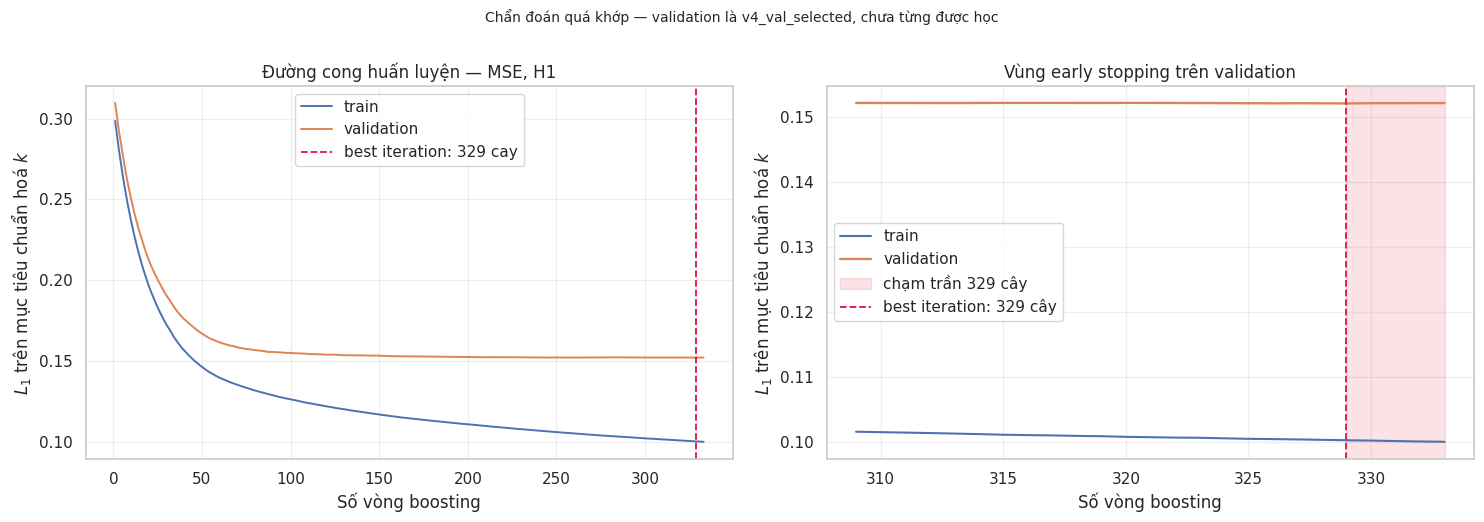


Giu nguyen 329 cay.


,so_cay,wape_train,wape_val,trong_vung_dung_som
0,329,14.461994,22.660302,True


In [15]:
# === DUONG CONG HUAN LUYEN ===
# Fit rieng mot ban co eval_set de lay evals_result_ (ban `model` o cell tren fit khong
# co eval_set nen khong co duong cong). Ban nay CHI dung de ve, khong thay the model.
import matplotlib.pyplot as plt

# Dung lich su cua model cuoi: cell nay KHONG fit/train them model nao.
_m_dc = model
_lich_su = LICH_SU_EARLY_STOP
SO_CAY_DUONG_CONG = int(model.best_iteration_)
BUOC_DO_DUONG_CONG = SO_CAY_DUONG_CONG

_Xva_dc = val_h[FEATURES].fillna(MEDIANS).astype(DTYPE)
_yva_dc = val_h['k_target'].astype(DTYPE)


def _wape_tai(khung, X, mask, so_cay):
    """WAPE that (kWh) khi chi dung `so_cay` cay dau tien."""
    _k = cat_k(_m_dc.predict(X, num_iteration=so_cay))
    _se = khung['sin_elevation'].to_numpy()
    _yp = np.minimum(_k * mau_chuan_hoa(khung),
                     khung['tran_cong_suat'].to_numpy() * 1.02)
    _yp = np.where(_se <= EPS_ELEV, 0.0, _yp)
    _yt = khung['y_true'].to_numpy()
    return float(np.nansum(np.abs(_yt[mask] - _yp[mask]))
                 / np.nansum(np.abs(_yt[mask])) * 100)


# Mask pham vi cong bo: xet NHAN tai T+h, khong phai cot tai T
def _mask_cong_bo(khung):
    _n = _cot_loc(khung, 'energy_source')
    _d = _cot_loc(khung, 'is_daylight')
    _m = (_n == 'measured').to_numpy() if _n is not None else np.ones(len(khung), bool)
    if _d is not None:
        _m = _m & _d.fillna(False).astype(bool).to_numpy()
    return _m


_dev_dc = dev_h.loc[X_dev.index]
_m_tr = _mask_cong_bo(_dev_dc)
_m_va = _mask_cong_bo(val_h)

_moc = list(range(BUOC_DO_DUONG_CONG, SO_CAY_DUONG_CONG + 1, BUOC_DO_DUONG_CONG))
_w_tr = [_wape_tai(_dev_dc, X_dev, _m_tr, i) for i in _moc]
_w_va = [_wape_tai(val_h, _Xva_dc, _m_va, i) for i in _moc]
_i_tot = int(np.argmin(_w_va))
_w_min = _w_va[_i_tot]

# VUNG BINH NGUYEN: moi moc co WAPE val nam trong nguong tuong doi so voi diem thap nhat.
# Them cay ngoai vung nay khong cai thien co y nghia, chi lam mo hinh nang va de qua khop.
DUNG_NGUONG = 0.001                      # 0,1% tuong doi
_trong_vung = [j for j, w in enumerate(_w_va) if w <= _w_min * (1 + DUNG_NGUONG)]
_j_dau, _j_cuoi = _trong_vung[0], _trong_vung[-1]
SO_CAY_KHUYEN_NGHI = _moc[_j_dau]        # nho nhat ma van dat -> re nhat, it qua khop nhat

print(f"WAPE val thap nhat  : {_w_min:.4f}% tai {_moc[_i_tot]} cay "
      f"(train cung moc {_w_tr[_i_tot]:.4f}%)")
print(f"Vung binh nguyen    : {_moc[_j_dau]} - {_moc[_j_cuoi]} cay "
      f"(WAPE val trong {DUNG_NGUONG*100:.1f}% so voi diem thap nhat)")
print(f"So cay khuyen nghi  : {SO_CAY_KHUYEN_NGHI}")
print(f"Dang dung           : {SO_CAY_DUONG_CONG} cay -> "
      f"{'DU, nen giam' if SO_CAY_KHUYEN_NGHI < SO_CAY_DUONG_CONG * 0.9 else 'hop ly'}")
print(f"Khoang cach train-val tai diem thap nhat: "
      f"{_w_va[_i_tot] - _w_tr[_i_tot]:+.4f} diem")

_fig, _ax = plt.subplots(1, 2, figsize=(15, 5.2))
_l_tr, _l_va = _lich_su['train']['l1'], _lich_su['val']['l1']
_x = np.arange(1, len(_l_tr) + 1)
_ax[0].plot(_x, _l_tr, lw=1.4, label='train')
_ax[0].plot(_x, _l_va, lw=1.4, label='validation')
_ax[0].set_xlabel('Số vòng boosting')
_ax[0].set_ylabel('$L_1$ trên mục tiêu chuẩn hoá $k$')
_ax[0].set_title(f'Đường cong huấn luyện — {LOSS_NAME.upper()}, H{HORIZON_STEPS}')
_ax[0].axvline(_m_dc.best_iteration_, ls='--', c='crimson', lw=1.3,
               label=f'best iteration: {_m_dc.best_iteration_} cay')
_ax[0].legend(); _ax[0].grid(alpha=.3)

_best, _end = int(_m_dc.best_iteration_), len(_l_va)
_start = max(1, _best - 20)
_x_zoom = np.arange(_start, _end + 1)
_ax[1].plot(_x_zoom, _l_tr[_start - 1:_end], lw=1.5, label='train')
_ax[1].plot(_x_zoom, _l_va[_start - 1:_end], lw=1.7, label='validation')
_span_label = (f'{_end - _best} vòng xác nhận không cải thiện'
               if _end >= _best + EARLY_STOPPING_ROUNDS
               else f'chạm trần {SO_CAY_DUONG_CONG} cây')
_ax[1].axvspan(_best, _end, color='crimson', alpha=.12, label=_span_label)
_ax[1].axvline(_best, ls='--', c='crimson', lw=1.3,
               label=f'best iteration: {_best} cây')
_ax[1].set_xlabel('Số vòng boosting')
_ax[1].set_ylabel('$L_1$ trên mục tiêu chuẩn hoá $k$')
_ax[1].set_title('Vùng early stopping trên validation')
_ax[1].legend(); _ax[1].grid(alpha=.3)
_fig.suptitle('Chẩn đoán quá khớp — validation là v4_val_selected, chưa từng được học',
              y=1.0, fontsize=10)
plt.tight_layout(); plt.show()

# ── Train lai mo hinh cuoi o so cay khuyen nghi ──
# Dat False neu muon giu nguyen so cay cua Optuna.
DUNG_SO_CAY_KHUYEN_NGHI = False  # early stopping da chon best_iteration_ tu validation

if DUNG_SO_CAY_KHUYEN_NGHI and SO_CAY_KHUYEN_NGHI < SO_CAY_DUONG_CONG:
    print(f"\nTrain lai mo hinh cuoi voi {SO_CAY_KHUYEN_NGHI} cay "
          f"(thay vi {SO_CAY_DUONG_CONG})...")
    BEST_PARAMS = {**BEST_PARAMS, 'n_estimators': SO_CAY_KHUYEN_NGHI}
    model = fit_an_toan(BEST_PARAMS, X_dev, y_dev, w_dev)

    # Du bao lai tren val de moi bang metric phia sau dung mo hinh moi
    _k2 = cat_k(model.predict(val_h[FEATURES].fillna(MEDIANS).astype(np.float32)))
    val_h['y_pred'] = np.minimum(_k2 * mau_chuan_hoa(val_h),
                                 val_h['tran_cong_suat'].to_numpy() * 1.02)
    val_h.loc[val_h['sin_elevation'] <= EPS_ELEV, 'y_pred'] = 0.0
    _m2 = metrics_3_pham_vi(val_h)['measured_daylight']
    print(f"WAPE val sau khi giam so cay: {_m2['wape']:.4f}%  (n={_m2['n']:,})")
    print("BEST_PARAMS da cap nhat -> cac cell export phia sau se ghi so cay moi.")
else:
    print(f"\nGiu nguyen {SO_CAY_DUONG_CONG} cay.")

pd.DataFrame({'so_cay': _moc, 'wape_train': _w_tr, 'wape_val': _w_va,
              'trong_vung_dung_som': [j in _trong_vung for j in range(len(_moc))]}).head(12)


## 13. Kiểm chứng trễ pha - phần quan trọng nhất của notebook

Đây là tiêu chí nghiệm thu: **dự báo phải đúng thời điểm**. Giá trị cao hay thấp hơn thực tế thì còn
chấp nhận được, nhưng nếu dự báo đến sau thì nó không còn là dự báo.


In [16]:
_quet = quet_do_tre(val_h)
_k_tot = min(_quet, key=_quet.get)
print("--- QUET DO TRE TOAN BO 42 TRAM ---")
print("So du bao(T) voi thuc te(T - k buoc). k=0 nho nhat la khong tre.\n")
for k, v in _quet.items():
    danh_dau = '  <== nho nhat' if k == _k_tot else ''
    print(f"   k={k} ({k * 15:>2} phut truoc): RMSE {v:.4f}{danh_dau}")
print(f"\nKết luận: {'KHONG TRE PHA' if _k_tot == 0 else f'TRE {_k_tot} BUOC = {_k_tot * 15} PHUT'}")

# quet rieng tung tram
_rows = []
for _s, _z in val_h[val_h['is_daylight'].fillna(False).astype(bool)].groupby(SITE_COL):
    _z = _z.sort_values(TIMESTAMP_COL)
    _r = {}
    for k in range(0, 3):
        _yt = _z['y_true'].shift(k)
        _m = _yt.notna()
        _r[k] = float(np.sqrt(np.mean((_z['y_pred'][_m] - _yt[_m]) ** 2)))
    _rows.append({'site_id': _s, 'k_tot_nhat': min(_r, key=_r.get),
                  'rmse_k0': round(_r[0], 4), 'rmse_k1': round(_r[1], 4), 'rmse_k2': round(_r[2], 4)})
df_tre = pd.DataFrame(_rows)
print("\n--- PHAN BO k TOT NHAT THEO TRAM ---")
print(df_tre['k_tot_nhat'].value_counts().sort_index().to_string())
print(f"\nSố trạm không trễ (k=0): {(df_tre['k_tot_nhat'] == 0).sum()}/{len(df_tre)}")
display(df_tre.head(10))


--- QUET DO TRE TOAN BO 42 TRAM ---
So du bao(T) voi thuc te(T - k buoc). k=0 nho nhat la khong tre.

   k=0 ( 0 phut truoc): RMSE 3.6502
   k=1 (15 phut truoc): RMSE 3.5290
   k=2 (30 phut truoc): RMSE 3.5062  <== nho nhat
   k=3 (45 phut truoc): RMSE 3.9763

Kết luận: TRE 2 BUOC = 30 PHUT

--- PHAN BO k TOT NHAT THEO TRAM ---
k_tot_nhat
0     2
1     7
2    31

Số trạm không trễ (k=0): 2/40


,site_id,k_tot_nhat,rmse_k0,rmse_k1,rmse_k2
0,1,1,2.5782,2.4663,2.4744
1,2,1,2.1973,2.1168,2.1623
2,3,1,1.6183,1.5472,1.5589
3,4,1,0.2353,0.2328,0.2365
4,5,2,0.2399,0.2319,0.2308
5,6,2,3.2107,3.0402,3.0306
6,7,0,1.7682,2.0702,2.4646
7,8,1,3.2081,3.1094,3.1554
8,9,2,0.2609,0.2545,0.2543
9,10,1,0.9802,0.9581,0.9737


## 14. Bảng metric ba phạm vi


In [17]:
_m = metrics_3_pham_vi(val_h)
_bang = pd.DataFrame(_m).T[['n', 'wape', 'rmse', 'mae', 'r2']].round(4)
print("--- METRIC TREN TAP TEST ---")
print("Con so chinh thuc de bao cao la dong measured_daylight.")
display(_bang)

# So voi persistence: du bao bang chinh gia tri gan nhat da biet
_v = val_h[val_h['is_daylight'].fillna(False).astype(bool)].sort_values([SITE_COL, TIMESTAMP_COL]).copy()
_v['persistence'] = _v.groupby(SITE_COL)[TARGET_COL].transform(lambda s: s)
_w_mo_hinh = compute_wape(_v['y_true'].values, _v['y_pred'].values)
_w_per = compute_wape(_v['y_true'].values, _v['persistence'].values)
print(f"\n--- SO VOI PERSISTENCE (chep gia tri gan nhat) ---")
print(f"   Persistence WAPE : {_w_per:.2f}%")
print(f"   Mo hinh WAPE     : {_w_mo_hinh:.2f}%")
print(f"   Skill score      : hon persistence {(_w_per - _w_mo_hinh) / _w_per * 100:.2f}%")


--- METRIC TREN TAP TEST ---
Con so chinh thuc de bao cao la dong measured_daylight.


,n,wape,rmse,mae,r2
all,288815.0,22.6603,3.6373,1.5478,0.9004
measured,288815.0,22.6603,3.6373,1.5478,0.9004
measured_daylight,288815.0,22.6603,3.6373,1.5478,0.9004



--- SO VOI PERSISTENCE (chep gia tri gan nhat) ---
   Persistence WAPE : 20.46%
   Mo hinh WAPE     : 22.66%
   Skill score      : hon persistence -10.74%


## 14.1. Bảng metric theo 8 phạm vi giống srcs

`srcs` không báo một con số duy nhất mà tách theo phạm vi, để thấy mô hình làm ăn thế nào trên từng loại
dòng. Con số **headline** là con số chính thức: `eligible` và `measured` và **không phải**
`physical_over_capacity`.

Điểm cần đọc trên bảng: `physical_over_capacity_rows` phải có sai số **rất lớn**. Đó là dấu hiệu tốt —
nghĩa là mô hình **không** học theo mấy dòng vượt trần vật lý đó, đúng như mong muốn.


In [18]:
_scopes = scope_masks(val_h)
_rows = []
for _ten, _mask in _scopes.items():
    _n = int(_mask.sum())
    if _n < 10:
        _rows.append({'pham_vi': _ten, 'so_dong': _n, 'wape_%': np.nan,
                      'rmse': np.nan, 'mae': np.nan, 'r2': np.nan})
        continue
    _z = val_h.loc[_mask]
    _mt = compute_metrics(_z['y_true'].values, _z['y_pred'].values)
    _rows.append({'pham_vi': _ten, 'so_dong': _n, 'wape_%': round(_mt['wape'], 4),
                  'rmse': round(_mt['rmse'], 4), 'mae': round(_mt['mae'], 4),
                  'r2': round(_mt['r2'], 4)})

df_scope = pd.DataFrame(_rows)
print("--- METRIC THEO 8 PHAM VI (giong scope_masks cua srcs) ---")
print("Con so CHINH THUC de bao cao la dong headline.")
display(df_scope)

_hl = df_scope[df_scope['pham_vi'] == 'headline']
if not _hl.empty and pd.notna(_hl['wape_%'].iloc[0]):
    print(f"\nHEADLINE WAPE = {_hl['wape_%'].iloc[0]:.4f}%  tren {int(_hl['so_dong'].iloc[0]):,} dong")

_pc = df_scope[df_scope['pham_vi'] == 'physical_over_capacity_rows']
_nr = df_scope[df_scope['pham_vi'] == 'normal_rows']
if not _pc.empty and not _nr.empty and pd.notna(_pc['wape_%'].iloc[0]) and pd.notna(_nr['wape_%'].iloc[0]):
    _ty = _pc['wape_%'].iloc[0] / _nr['wape_%'].iloc[0]
    print(f"WAPE tai physical_over_capacity gap {_ty:.1f} lan so voi normal_rows.")
    if _ty > 2:
        print("   TOT: mo hinh KHONG hoc theo may dong vuot tran vat ly.")
    else:
        print("   [CANH BAO] Ty le nay thap, co the mo hinh dang hoc ca outlier vuot tran.")


--- METRIC THEO 8 PHAM VI (giong scope_masks cua srcs) ---
Con so CHINH THUC de bao cao la dong headline.


,pham_vi,so_dong,wape_%,rmse,mae,r2
0,eligible_rows,288815,22.6603,3.6373,1.5478,0.9004
1,headline,288815,22.6603,3.6373,1.5478,0.9004
2,normal_rows,286900,22.3651,3.5692,1.5250,0.9039
3,etl_imputed_rows,0,NaN,NaN,NaN,NaN
4,gmm_if_consensus_rows,1578,51.2696,8.7864,4.5630,0.5685
5,physical_over_capacity_rows,0,NaN,NaN,NaN,NaN
6,other_physical_rule_rows,172,66.9290,8.3371,4.8087,0.0201
7,multiple_rules_rows,165,124.8317,14.0011,8.9602,-0.6996



HEADLINE WAPE = 22.6603%  tren 288,815 dong


## 14.2. Trực quan hoá chính sách sample weight

Ba việc cần thấy:

1. Số dòng của từng nhóm `outlier_group` và bao nhiêu trong đó được đưa vào hàm mục tiêu
2. WAPE theo từng phạm vi — cột `physical_over_capacity_rows` phải cao vọt lên
3. Dự báo so với thực tế **tại chính các dòng outlier** — đường dự báo phải **không** đuổi theo phốc


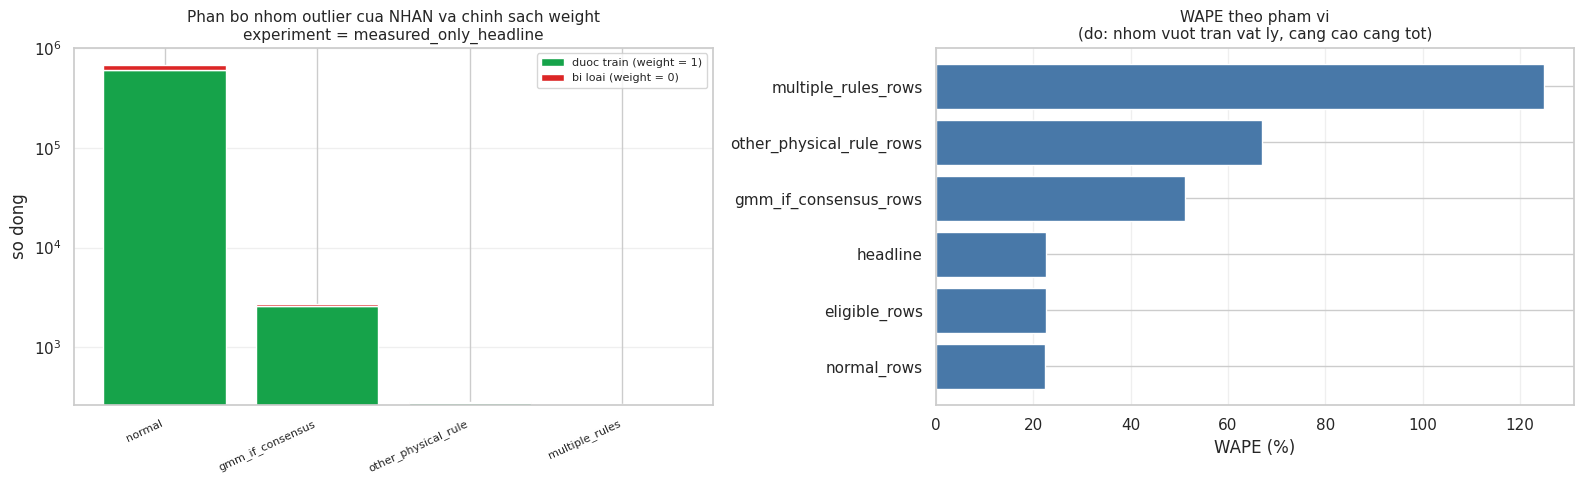

--- BANG CHI TIET NHOM OUTLIER TRONG TAP TRAIN ---


,nhan_outlier_group,tong,duoc_train,bi_loai
2,normal,678240,596030,82210
0,gmm_if_consensus,2740,2599,141
3,other_physical_rule,287,280,7
1,multiple_rules,269,265,4


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

_g = dev_h.groupby('nhan_outlier_group', observed=True).agg(
    tong=('w', 'size'), duoc_train=('w', lambda x: int((x > 0).sum()))).reset_index()
_g['bi_loai'] = _g['tong'] - _g['duoc_train']
_g = _g.sort_values('tong', ascending=False)
_x = np.arange(len(_g))
axes[0].bar(_x, _g['duoc_train'], color='#16a34a', label='duoc train (weight = 1)')
axes[0].bar(_x, _g['bi_loai'], bottom=_g['duoc_train'], color='#dc2626', label='bi loai (weight = 0)')
axes[0].set_xticks(_x)
axes[0].set_xticklabels(_g['nhan_outlier_group'], rotation=25, ha='right', fontsize=8)
axes[0].set_title(f"Phan bo nhom outlier cua NHAN va chinh sach weight\nexperiment = {EXPERIMENT}", fontsize=11)
axes[0].set_ylabel('so dong')
axes[0].set_yscale('log')
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3, axis='y')

_p = df_scope.dropna(subset=['wape_%']).sort_values('wape_%')
_col = ['#dc2626' if 'physical_over_capacity' in t else '#4878a8' for t in _p['pham_vi']]
axes[1].barh(_p['pham_vi'], _p['wape_%'], color=_col)
axes[1].set_xlabel('WAPE (%)')
axes[1].set_title('WAPE theo pham vi\n(do: nhom vuot tran vat ly, cang cao cang tot)', fontsize=11)
axes[1].grid(alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

print("--- BANG CHI TIET NHOM OUTLIER TRONG TAP TRAIN ---")
display(_g)


### Nhận xét về xử lý outlier

Cách làm này giống `srcs`: **không xoá dòng outlier khỏi dữ liệu**, chỉ đặt `sample_weight = 0` để chúng
không tham gia hàm mục tiêu. Nhờ vậy vẫn giữ được dòng để báo cáo theo phạm vi, và biết được mô hình
hành xử thế nào trên chúng.

Nhóm được xét là nhóm của **dòng nhãn** `y(T+h)`, không phải dòng đặc trưng. Đúng logic: nếu giá trị cần
dự báo là outlier thì mới không nên học theo nó.

Nếu WAPE tại `physical_over_capacity_rows` gần bằng `normal_rows` thì mô hình vẫn đang bám theo phốc
outlier, phải xem lại `build_sample_weight` đã áp đúng chưa.


## 15. Trực quan hoá - phóng to quanh đỉnh từng trạm

Vẽ cửa sổ 5 giờ quanh đỉnh của ngày nhiều nắng nhất. Trục thời gian chia mốc 15 phút để nhìn rõ
có lệch bước nào không. Tiêu đề mỗi ô ghi RMSE theo `k` để đối chiếu bằng số ngay trên hình.


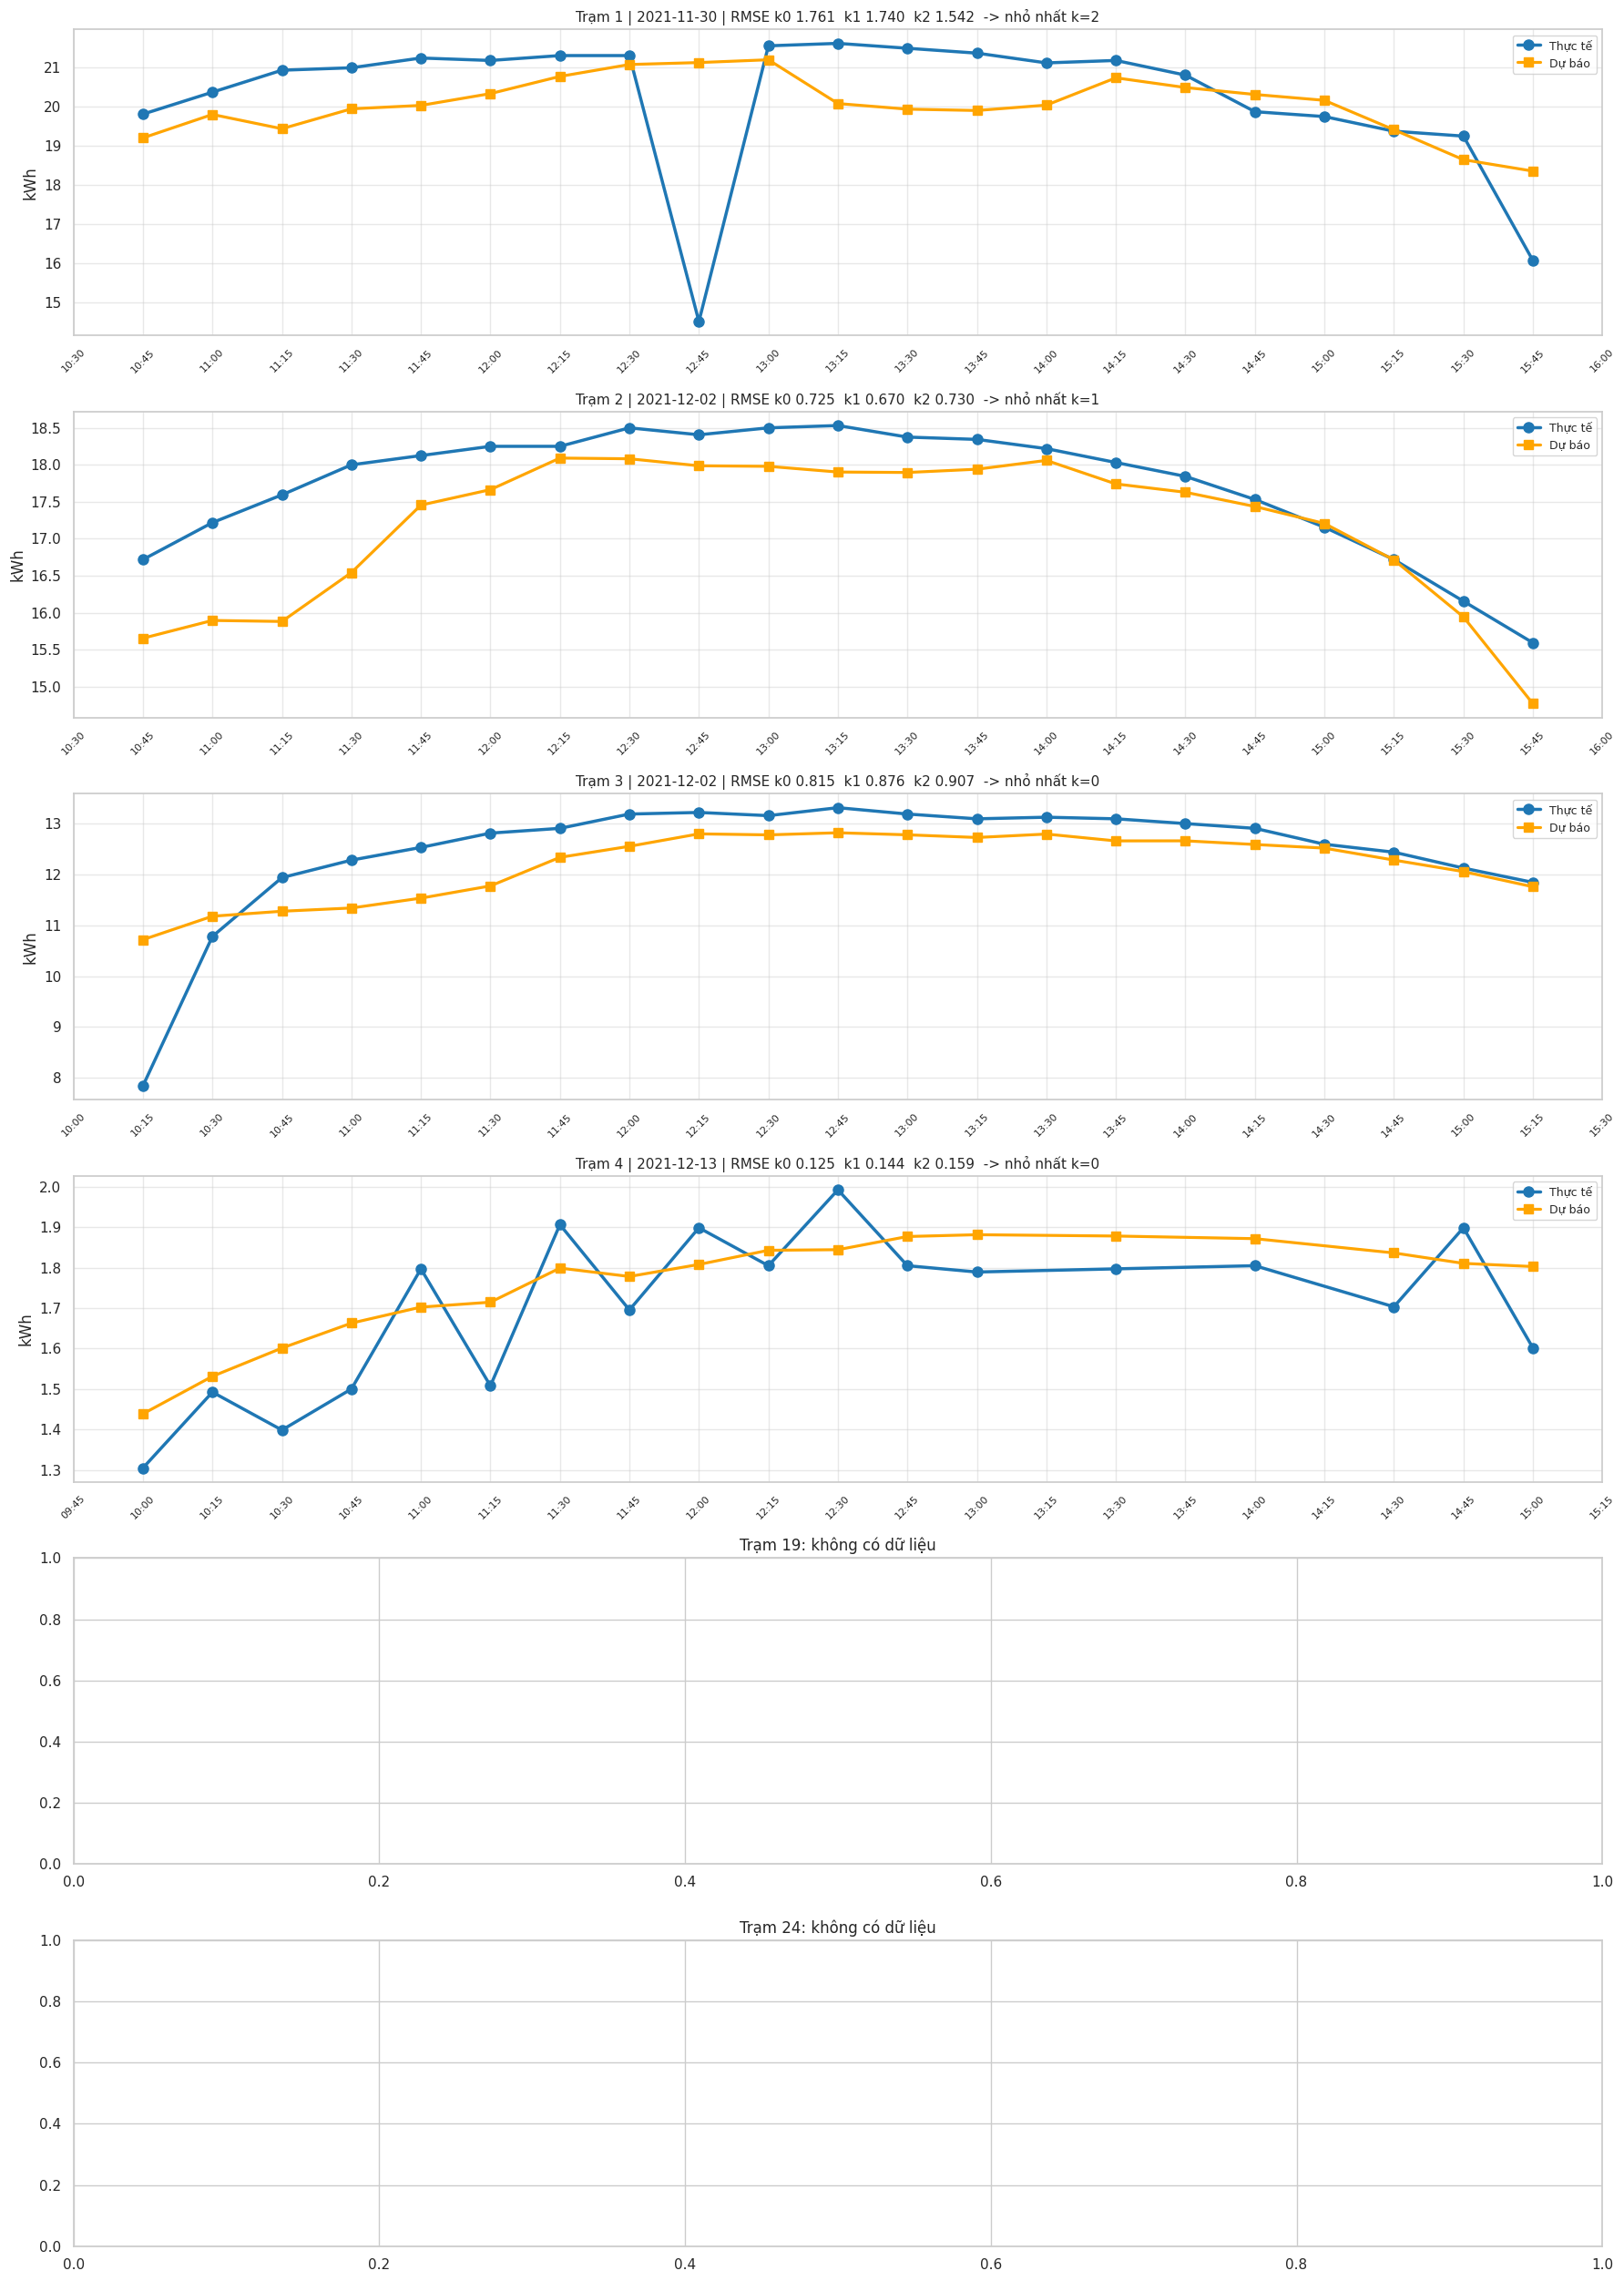

Đã lưu ../../data/model/v4/06_3_train_mse/zoom_quanh_dinh.png


In [20]:
SITE_VE = [1, 2, 3, 4, 19, 24]
fig, axes = plt.subplots(len(SITE_VE), 1, figsize=(18, 4.2 * len(SITE_VE)))
_t = val_h.copy()
_t['ngay'] = _t['plot_timestamp'].dt.date
for ax, s in zip(np.atleast_1d(axes), SITE_VE):
    x = _t[_t[SITE_COL] == s]
    if x.empty:
        ax.set_title(f'Trạm {s}: không có dữ liệu')
        continue
    ngay = x.groupby('ngay')['y_true'].sum().idxmax()
    z = x[x['ngay'] == ngay].sort_values('plot_timestamp')
    tpk = z.loc[z['y_true'].idxmax(), 'plot_timestamp']
    z = z[z['plot_timestamp'].between(tpk - pd.Timedelta(hours=2, minutes=30),
                                     tpk + pd.Timedelta(hours=2, minutes=30))]
    ax.plot(z['plot_timestamp'], z['y_true'], '-o', ms=8, lw=2.5, color='#1f77b4', label='Thực tế')
    ax.plot(z['plot_timestamp'], z['y_pred'], '-s', ms=7, lw=2.3, color='#FFA500', label='Dự báo')
    r = {k: float(np.sqrt(((z['y_pred'] - z['y_true'].shift(k)).dropna() ** 2).mean())) for k in range(0, 3)}
    ax.set_title(f"Trạm {s} | {ngay} | RMSE k0 {r[0]:.3f}  k1 {r[1]:.3f}  k2 {r[2]:.3f}"
                 f"  -> nhỏ nhất k={min(r, key=r.get)}", fontsize=11)
    ax.xaxis.set_major_locator(mdates.MinuteLocator(interval=15))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
    ax.grid(alpha=0.45)
    ax.legend(fontsize=9)
    ax.set_ylabel('kWh')
    plt.setp(ax.get_xticklabels(), rotation=45, fontsize=8)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/zoom_quanh_dinh.png', dpi=100)
plt.show()
print(f"Đã lưu {OUTPUT_DIR}/zoom_quanh_dinh.png")


### Nhận xét

Nếu khử trễ thành công thì trên hình phải thấy: **sườn lên và sườn xuống của hai đường trùng nhịp nhau**.
Phần còn lại là đường dự báo nằm thấp hơn ở đoạn đỉnh phẳng, đó là lệch **độ cao** do inverter cắt đỉnh,
không phải lệch **thời gian**. Tiêu đề mỗi ô phải ghi `nhỏ nhất k=0`.

Nếu còn ô nào ghi `k=1` hoặc `k=2` thì trạm đó vẫn còn dư trễ, cần soi riêng.


## 16. Vẽ toàn cảnh một tuần để nhìn tổng thể


--- CHON TRAM DE VE (5 tram dan dau) ---
         ty_le_do_that  dinh  bien_thien_dinh
site_id                                      
27                99.7  85.9             37.9
8                 98.1  27.0             26.6
6                 97.4  28.7             23.4
12                97.3  17.6             23.4
13                97.0  12.9             23.7

Chon tram 27: do that 99.7%, dinh 85.9 kWh, bien thien dinh 37.9%


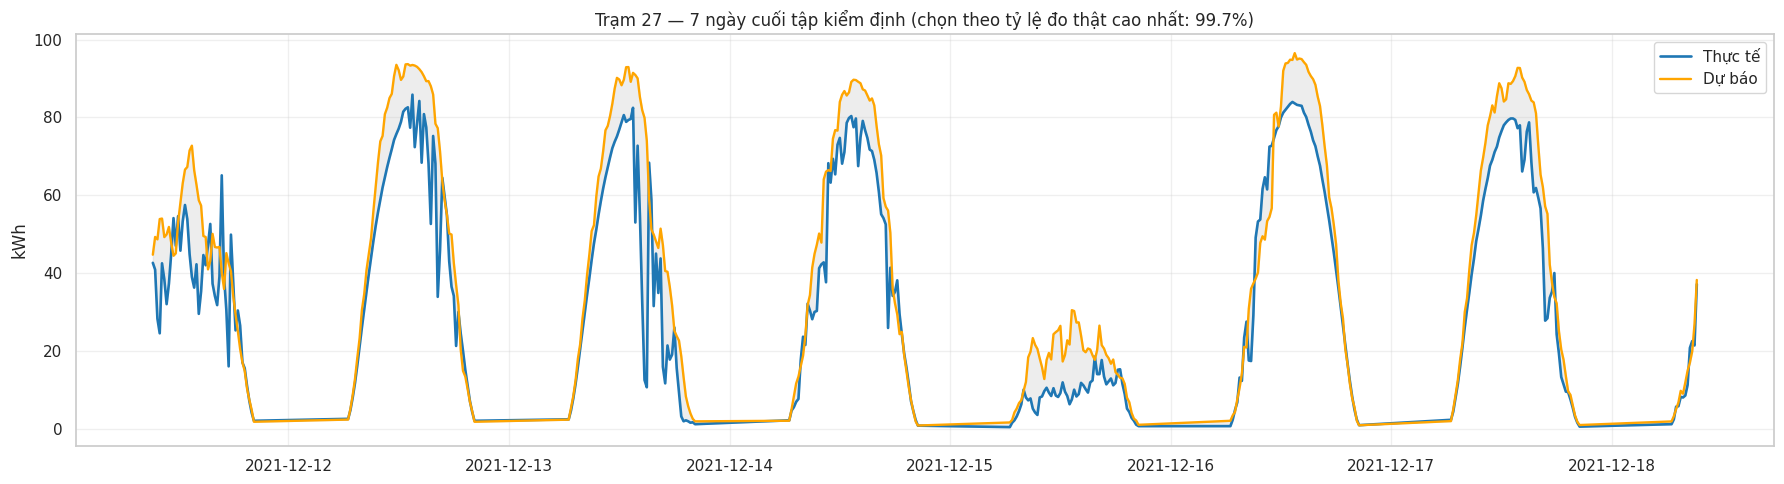

Đã lưu ../../data/model/v4/06_3_train_mse/toan_canh_1_tuan.png


In [21]:
# Chon tram de ve THEO TIEU CHI DO DUOC, khong gan tay.
# Ly do: tram gan tay co the roi vao tram co dinh bi chan lap lai gan y het moi ngay
# (inverter bao hoa, vd tram 3: dinh 13,40 kWh lap 4/8 ngay) nen duong ve ra phang,
# khong the hien duoc kha nang bam bien thien cua mo hinh. Tieu chi duoi day chon tram
# co ty le DO THAT cao nhat trong cua so ve, tie-break bang muc bien thien dinh giua
# cac ngay -> hinh phan anh du lieu that, va tieu chi duoc in ra de kiem chung lai.
_w = _t[_t['plot_timestamp'] >= _t['plot_timestamp'].max() - pd.Timedelta(days=7)].copy()
_w['_do_that'] = (_w['energy_source'] == 'measured') if 'energy_source' in _w.columns else True
_dnn = _w.groupby([SITE_COL, _w['plot_timestamp'].dt.date])['y_true'].max()

_bang = pd.DataFrame({
    'ty_le_do_that':   _w.groupby(SITE_COL)['_do_that'].mean() * 100,
    'dinh':            _w.groupby(SITE_COL)['y_true'].max(),
    'bien_thien_dinh': _dnn.groupby(level=0).std() / _dnn.groupby(level=0).mean() * 100,
}).dropna()
_bang = _bang[_bang['dinh'] > 8]          # bo tram cong suat qua nho, ve ra deo sat truc
_bang = _bang.sort_values(['ty_le_do_that', 'bien_thien_dinh'], ascending=False)

SITE_TUAN = int(_bang.index[0])
print("--- CHON TRAM DE VE (5 tram dan dau) ---")
print(_bang.head(5).round(1).to_string())
print(f"\nChon tram {SITE_TUAN}: do that {_bang.iloc[0]['ty_le_do_that']:.1f}%, "
      f"dinh {_bang.iloc[0]['dinh']:.1f} kWh, bien thien dinh {_bang.iloc[0]['bien_thien_dinh']:.1f}%")

x = _t[_t[SITE_COL] == SITE_TUAN].sort_values('plot_timestamp')
t_cuoi = x['plot_timestamp'].max()
z = x[x['plot_timestamp'] >= t_cuoi - pd.Timedelta(days=7)]
fig, ax = plt.subplots(figsize=(18, 5))
ax.plot(z['plot_timestamp'], z['y_true'], lw=1.9, color='#1f77b4', label='Thực tế')
ax.plot(z['plot_timestamp'], z['y_pred'], lw=1.7, color='#FFA500', label='Dự báo')
ax.fill_between(z['plot_timestamp'], z['y_true'], z['y_pred'], color='#cccccc', alpha=0.35)
ax.set_title(f'Trạm {SITE_TUAN} — 7 ngày cuối tập kiểm định '
             f'(chọn theo tỷ lệ đo thật cao nhất: {_bang.iloc[0]["ty_le_do_that"]:.1f}%)', fontsize=12)
ax.set_ylabel('kWh')
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/toan_canh_1_tuan.png', dpi=100)
plt.show()
print(f"Đã lưu {OUTPUT_DIR}/toan_canh_1_tuan.png")


## 17. Export kết quả


In [22]:

with open(f'{OUTPUT_DIR}/model_h1.pkl', 'wb') as f:
    pickle.dump({'model': model, 'features': FEATURES, 'medians': MEDIANS.to_dict(),
                 'eps_elev': EPS_ELEV, 'clip_k': lay_clip(), 'horizon_steps': HORIZON_STEPS,
                 'loss': LOSS_NAME, 'chuan_hoa': True}, f)

df_tre.to_csv(f'{OUTPUT_DIR}/tre_pha_theo_tram.csv', index=False)
_bang.to_csv(f'{OUTPUT_DIR}/metrics.csv')
with open(f'{OUTPUT_DIR}/ket_qua.json', 'w', encoding='utf-8') as f:
    json.dump({'loss': LOSS_NAME, 'horizon_steps': HORIZON_STEPS,
               'so_dac_trung': len(FEATURES), 'features': FEATURES,
               'bo_di': bo_di, 'best_params': BEST_PARAMS,
               'quet_do_tre': {str(k): v for k, v in _quet.items()},
               'k_tot_nhat': int(_k_tot),
               'so_tram_khong_tre': int((df_tre['k_tot_nhat'] == 0).sum()),
               'metrics': _m}, f, indent=2, ensure_ascii=False, default=str)

print("--- HOAN TAT ---")
print(f"Thư mục kết quả: {OUTPUT_DIR}")
for _f in sorted(os.listdir(OUTPUT_DIR)):
    print(f"   {_f}")

# ── Ghi thêm bộ artifact theo đúng định dạng mà notebook 07 và 08 mong đợi ──
# 07 quét thư mục 06_train/<loss>/<h_label>/ nên phải ghi vào đúng cấu trúc đó.
TRAIN_COMPAT_DIR = f'../../data/model/v4/06_train/{LOSS_NAME}/h{HORIZON_STEPS}'
os.makedirs(TRAIN_COMPAT_DIR, exist_ok=True)

with open(f'{TRAIN_COMPAT_DIR}/model.pkl', 'wb') as f:
    pickle.dump(model, f)                      # model tho, de 07 goi model.predict duoc

with open(f'{TRAIN_COMPAT_DIR}/model_config.json', 'w', encoding='utf-8') as f:
    json.dump({
        'horizon_steps': int(HORIZON_STEPS),
        'loss_name': LOSS_NAME,
        'feature_set_name': '',
        'excluded_features': bo_di,
        'lgb_objective': LGB_OBJECTIVE,
        'features': FEATURES,
        'feature_medians': {k: float(v) for k, v in MEDIANS.items()},
        'train_rows': int(len(X_dev)),
        # ba khoa duoi day cho biet phai nhan nguoc mau chuan hoa khi du bao
        # Quy mo va tran cong suat da nam san trong du lieu duoi dang cot, sinh o notebook 03-2.
        # Khi cham diem chi can nhan nguoc site_scale * sin_elevation roi chan tran_cong_suat.
        'chuan_hoa': True,
        'cot_quy_mo': 'site_scale',
        'cot_sin_elev': 'sin_elevation',
        'cot_tran': 'tran_cong_suat',
        'eps_elev': float(EPS_ELEV),
                    'clip_k': float(lay_clip()),
                    'mau_so': MAU_SO,
        'model_params': {k: v for k, v in BEST_PARAMS.items()
                         if k not in ('device', 'gpu_platform_id', 'gpu_device_id')},
    }, f, indent=2, ensure_ascii=False)


# FIX (chong ro ri): metrics_val.json de notebook 07 quet va chon mo hinh vo dich BAT BUOC
# phai tinh tren tap VALIDATION that, khong duoc dung _m (dang tinh tren val_h). Truoc day
# file nay bi ghi nham tu _m (tap test) khien viec chon MAE/Huber/MSE "thay truoc" tap test.
# Tap VAL that - tach biet hoan toan voi tap hoc (mo hinh chi hoc v4_train_selected).
val_h = doc_val_that()
_k_pred_val = cat_k(model.predict(val_h[FEATURES].fillna(MEDIANS).astype(np.float32)))
val_h['y_pred'] = np.minimum(_k_pred_val * mau_chuan_hoa(val_h), val_h['tran_cong_suat'].to_numpy() * 1.02)
val_h.loc[val_h['sin_elevation'] <= EPS_ELEV, 'y_pred'] = 0.0
_m_val = metrics_3_pham_vi(val_h)
print(f"--- METRIC TREN TAP VALIDATION THAT ({len(val_h):,} dong, dung de chon mo hinh) ---")
display(pd.DataFrame(_m_val).T[['n', 'wape', 'rmse', 'mae', 'r2']].round(4))

_val_scope = _m_val.get('measured_daylight', _m_val.get('measured', _m_val['all']))
with open(f'{TRAIN_COMPAT_DIR}/metrics_val.json', 'w', encoding='utf-8') as f:
    json.dump({'horizon_steps': int(HORIZON_STEPS), 'loss_name': LOSS_NAME,
               'feature_set_name': '', 'measured_daylight': _val_scope,
               'all': _m_val['all']}, f, indent=2, ensure_ascii=False, default=str)


# Ma tran test da san sang, kem cac cot can de dung lai du bao.
# 07 va 08 doc file nay thay vi tu dung lai dac trung, tranh lech logic.

print(f"\nĐã ghi bộ artifact tương thích notebook 07/08 vào: {TRAIN_COMPAT_DIR}")
for _f in sorted(os.listdir(TRAIN_COMPAT_DIR)):
    print(f"   {_f}")


--- HOAN TAT ---
Thư mục kết quả: ../../data/model/v4/06_3_train_mse
   ket_qua.json
   metrics.csv
   model_h1.pkl
   toan_canh_1_tuan.png
   tre_pha_theo_tram.csv
   zoom_quanh_dinh.png


    Loai [19, 24] (capacity_kw khong dang tin): 702,233 -> 668,714 dong
Lọc v4_val_selected: 723,114 -> 668,714 dòng (50 cột)


--- METRIC TREN TAP VALIDATION THAT (288,815 dong, dung de chon mo hinh) ---


,n,wape,rmse,mae,r2
all,288815.0,22.6603,3.6373,1.5478,0.9004
measured,288815.0,22.6603,3.6373,1.5478,0.9004
measured_daylight,288815.0,22.6603,3.6373,1.5478,0.9004



Đã ghi bộ artifact tương thích notebook 07/08 vào: ../../data/model/v4/06_train/mse/h1
   metrics_val.json
   model.pkl
   model_config.json


## 18. Nguồn tham khảo

### Phương pháp downscale bức xạ bằng chỉ số trời quang
- Temporal and spatial downscaling for solar radiation - https://arxiv.org/pdf/2405.11046
- Intra-hour irradiance forecasting techniques for solar power integration: a review -
  https://pmc.ncbi.nlm.nih.gov/articles/PMC8531863/
- Short-term photovoltaic generation forecasting using multiple heterogenous sources of data -
  https://arxiv.org/pdf/1910.05944
- A fully convolutional neural network to interpolate solar irradiation NWP ensemble forecasts -
  https://www.sciencedirect.com/science/article/pii/S0038092X25006280
- Review of Onsite Temperature and Solar Forecasting Models (NREL/OSTI) -
  https://www.osti.gov/servlets/purl/1855958

Thuật toán tách chỉ số trời quang theo giờ thành thành phần xu thế và nhiễu của Graham và Hollands là
cơ sở cho cách làm ở mục 6. Điểm khác biệt của notebook này là **không nội suy giữa các giờ** để giữ
tính nhân quả, chỉ dùng phép nhân với bức xạ trời quang 15 phút.

### Công thức góc mặt trời
- NOAA Solar Calculator, phương trình thời gian và độ lệch mặt trời -
  https://gml.noaa.gov/grad/solcalc/calcdetails.html

### Mô hình bức xạ trời quang
- Haurwitz clear-sky model, dạng `GHI = 1098 x sin(h) x exp(-0.057 / sin(h))`

### Hiện tượng mô hình hội tụ về persistence
Việc mô hình có đặc trưng tự hồi quy trên chuỗi tự tương quan cao sẽ hội tụ về dự báo naive là hiện tượng
đã được ghi nhận trong các tổng quan về dự báo bức xạ nội giờ ở trên. Cách xử lý chuẩn của ngành là báo cáo
**skill score so với persistence** thay vì chỉ báo WAPE trần - đã cài ở mục 14.


## 19. TRAIN H4 (chạy SAU khi H1 đã ổn định)

**⚠️ CẢNH BÁO Restart & Run All: 4 cell dưới đây SẼ TỰ CHẠY và train luôn H4 (tốn thêm cả
tiếng CPU/GPU) nếu bấm "Run All" trên toàn bộ notebook.** Nếu CHỈ muốn train H1 trước (khuyến
nghị), sau khi cell "17. Export kết quả" (H1) chạy xong thì DỪNG LẠI, đừng bấm Run All tiếp —
hoặc xoá/comment tạm nội dung 4 cell H4 này. Khi nào muốn train H4, quay lại chạy tay 4 cell
này (Shift+Enter từng cell), không cần chạy lại từ đầu notebook.

Dùng lại TOÀN BỘ hàm đã định nghĩa ở phần H1 phía trên (`them_muc_tieu`, `build_sample_weight`,
`doc_fold`, `tham_so_co_ban`, `fit_an_toan`, `du_bao_kwh`, `quet_do_tre`, `metrics_3_pham_vi`) —
không định nghĩa lại. Các hàm này đọc `HORIZON_STEPS`/`OUTPUT_DIR` từ biến toàn cục, nên chỉ cần
gán lại 2 biến đó rồi chạy lại đúng luồng train (build target → Optuna → train final → export).

**Điều kiện tiên quyết:** đã chạy xong tới hết phần H1 phía trên trong CÙNG 1 phiên kernel (để
có sẵn `dev`, `test`, `FEATURES` gốc, các hàm/imports...) — không cần chạy lại từ đầu notebook,
nhưng bắt buộc phải chạy H1 trước ít nhất 1 lần trong kernel đang mở.

In [23]:
# ── Chuyen sang HORIZON_STEPS = 4, OUTPUT_DIR rieng (khong dung H1) ──
HORIZON_STEPS = 4
OUTPUT_DIR = '../../data/model/v4/06_3_train_mse_h4'
os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"Chuyen sang train H4 (T+{HORIZON_STEPS * 15} phut). Ghi ket qua vao: {OUTPUT_DIR}")

# Build lai target/weight cho H4 - GIONG HET logic cell 'Chuan bi ma tran huan luyen' o
# phan H1 (buoc 10), chi khac HORIZON_STEPS. FEATURES_GOC luu lai truoc khi them cot _mt,
# de neu chay lai cell nay nhieu lan khong bi cong don _mt trung.
if 'FEATURES_GOC' not in dir():
    FEATURES_GOC = list(FEATURES)
FEATURES = list(FEATURES_GOC)

dev_h = them_muc_tieu(dev, HORIZON_STEPS)
dev_h = dev_h[(dev_h['site_scale'] > 0) & (dev_h['sin_elevation'] > EPS_ELEV)].copy()
dev_h['k_target'] = cat_k(dev_h['y_true'].to_numpy() / mau_chuan_hoa(dev_h))
dev_h['w'] = build_sample_weight(dev_h)

_mt = [f'{c}_mt' for c in COT_TAT_DINH if f'{c}_mt' in dev_h.columns]
FEATURES = FEATURES + [c for c in _mt if c not in FEATURES]
print(f"Them {len(_mt)} dac trung tat dinh tai T+{HORIZON_STEPS * 15} phut: {_mt}")

MEDIANS = dev_h[FEATURES].median(numeric_only=True).fillna(0.0)
_train_mask = dev_h['w'].gt(0)
X_dev = dev_h.loc[_train_mask, FEATURES].fillna(MEDIANS).astype(DTYPE)
y_dev = dev_h.loc[_train_mask, 'k_target'].astype(DTYPE)
w_dev = dev_h.loc[_train_mask, 'w'].astype(DTYPE)
print(f"Ma tran train H4: {X_dev.shape[0]:,} dong x {X_dev.shape[1]} dac trung")

# ── Cong kiem tra nhanh truoc train H4 (rut gon tu buoc 10.2, chi kiem C va D vi A/B
# khong doi theo horizon) ──
_loi_h4 = []
_b4 = dev_h[dev_h['w'].gt(0)]
_t4 = dev_h.copy()
_t4['duoc_train'] = _t4['w'] > 0
_bo4 = (_t4.groupby(SITE_COL, observed=True)['duoc_train'].apply(lambda x: 1 - x.mean()).mul(100).round(1))
_nang4 = _bo4[_bo4 > 50]
print(f"[D-H4] Site bi loai > 50% dong ban ngay: {len(_nang4)}/{_bo4.size}")
if len(_nang4):
    print(_nang4.to_string())
    _loi_h4.append(f"D-H4: {len(_nang4)} site bi loai qua nua du lieu ban ngay o horizon H4.")
del _t4, _b4
gc.collect()

if _loi_h4:
    raise RuntimeError(f"Cong kiem tra H4 khong dat ({len(_loi_h4)} loi): {_loi_h4}")
print("CONG KIEM TRA H4: DAT - cho train.")


Chuyen sang train H4 (T+60 phut). Ghi ket qua vao: ../../data/model/v4/06_3_train_mse_h4


Them 14 dac trung tat dinh tai T+60 phut: ['solar_elevation_mt', 'solar_azimuth_mt', 'azimuth_sin_mt', 'azimuth_cos_mt', 'sin_elevation_mt', 'ghi_cs_mt', 'ky_vong_mt', 'ty_le_bao_hoa_mt', 'minute_of_day_mt', 'hour_mt', 'hour_sin_mt', 'hour_cos_mt', 'doy_sin_mt', 'doy_cos_mt']


Ma tran train H4: 566,594 dong x 54 dac trung
[D-H4] Site bi loai > 50% dong ban ngay: 0/40


CONG KIEM TRA H4: DAT - cho train.


In [24]:
# ── Optuna tune + train final cho H4 (dung lai doc_fold/tham_so_co_ban/fit_an_toan da
# dinh nghia o phan H1 - cac ham nay doc HORIZON_STEPS tu bien toan cuc nen tu dong dung
# cho H4 sau khi cell tren da gan lai HORIZON_STEPS = 4) ──
CAC_FOLD = []
if N_TRIALS > 0:
    _n = 1
    while True:
        _tr = doc_fold(_n, 'train')
        _va = doc_fold(_n, 'val')
        if _tr is None or _va is None:
            break
        _med = _tr[FEATURES].median(numeric_only=True).fillna(0.0)
        CAC_FOLD.append({
            'fold': _n,
            'Xtr': _tr[FEATURES].fillna(_med).astype(DTYPE),
            'ytr': _tr['k_target'].astype(DTYPE),
            'wtr': _tr['w'].astype(DTYPE),
            'Xva': _va[FEATURES].fillna(_med).astype(DTYPE),
            'yva': _va['k_target'].astype(DTYPE),
            'yva_kwh': _va['y_true'].to_numpy(),
            'mau_va': mau_chuan_hoa(_va),
            'tran_va': _va['tran_cong_suat'].to_numpy(),
            'sin_va': _va['sin_elevation'].to_numpy(),
        })
        print(f"- fold {_n}: train {len(_tr):,} dong, val {len(_va):,} dong (H4, da ap weight)")
        del _tr, _va
        gc.collect()
        _n += 1
    if not CAC_FOLD:
        raise FileNotFoundError(f"Khong tim thay fold nao trong {FOLDS_DIR}.")
    print(f"\nDa nap {len(CAC_FOLD)} fold cho H4.")

    _t0_h4 = time.time()

    def objective_h4(trial):
        params = tham_so_co_ban(trial)
        tong_sai_so = 0.0
        tong_thuc_te = 0.0
        _cay_tung_fold = []
        for f in CAC_FOLD:
            m = fit_an_toan(params, f['Xtr'], f['ytr'], f['wtr'], f['Xva'], f['yva'])
            _cay_tung_fold.append(int(m.best_iteration_ or params['n_estimators']))
            yp = du_bao_kwh(m, f, m.best_iteration_)
            tong_sai_so += float(np.abs(yp - f['yva_kwh']).sum())
            tong_thuc_te += float(np.abs(f['yva_kwh']).sum())
            del m
        trial.set_user_attr('so_cay_tung_fold', _cay_tung_fold)
        return tong_sai_so / tong_thuc_te * 100.0 if tong_thuc_te > 0 else np.nan

    def log_trial_h4(study, trial):
        done = trial.number + 1
        el = (time.time() - _t0_h4) / 60
        val = f"{trial.value:.4f}%" if trial.value is not None else "pruned"
        print(f"   [H4 Trial {done:>2}/{N_TRIALS}] pooled WAPE {val:>10} | tot nhat {study.best_value:.4f}% "
              f"| da chay {el:.1f} phut, con khoang {el / done * (N_TRIALS - done):.1f} phut")

    study_h4 = optuna.create_study(direction='minimize', sampler=TPESampler(seed=SEED))
    study_h4.optimize(objective_h4, n_trials=N_TRIALS, show_progress_bar=False, callbacks=[log_trial_h4])
    BEST_PARAMS = tham_so_co_ban()
    BEST_PARAMS.update(study_h4.best_params)
    print(f"\nPooled WAPE tot nhat H4 tren {len(CAC_FOLD)} fold = {study_h4.best_value:.4f}%")
    del CAC_FOLD
    gc.collect()
else:
    BEST_PARAMS = tham_so_co_ban()
    print("N_TRIALS = 0 nen bo qua Optuna H4, dung tham so mac dinh.")

val_h = doc_val_that()   # dung lai theo HORIZON_STEPS hien tai (H4)
_X_val_es = val_h[FEATURES].fillna(MEDIANS).astype(DTYPE)
_y_val_es = val_h['k_target'].astype(DTYPE)
LICH_SU_EARLY_STOP = {}
_t1_h4 = time.time()
model = fit_an_toan(BEST_PARAMS, X_dev, y_dev, w_dev, _X_val_es, _y_val_es, LICH_SU_EARLY_STOP)
BEST_PARAMS = {**BEST_PARAMS, 'n_estimators': int(model.best_iteration_)}
print(f"Train H4 xong sau {(time.time() - _t1_h4) / 60:.1f} phut | dung som tai {model.best_iteration_} cay")

_k_pred = cat_k(model.predict(val_h[FEATURES].fillna(MEDIANS).astype(np.float32)))
val_h['y_pred'] = np.minimum(_k_pred * mau_chuan_hoa(val_h), val_h['tran_cong_suat'].to_numpy() * 1.02)
val_h.loc[val_h['sin_elevation'] <= EPS_ELEV, 'y_pred'] = 0.0
print(f"Da du bao {len(val_h):,} dong (H4)")


- fold 1: train 91,608 dong, val 180,394 dong (H4, da ap weight)


- fold 2: train 306,802 dong, val 244,595 dong (H4, da ap weight)


- fold 3: train 567,496 dong, val 272,569 dong (H4, da ap weight)

Da nap 3 fold cho H4.


Training until validation scores don't improve for 100 rounds


Early stopping, best iteration is:
[54]	train's l1: 0.10477	train's l2: 0.0221999	val's l1: 0.243179	val's l2: 0.100522
Evaluated only: l1


...

Training until validation scores don't improve for 100 rounds


[200]	train's l1: 0.133505	train's l2: 0.032565	val's l1: 0.182016	val's l2: 0.058143


[400]	train's l1: 0.115675	train's l2: 0.0254889	val's l1: 0.181095	val's l2: 0.0580847


Did not meet early stopping. Best iteration is:
[509]	train's l1: 0.109536	train's l2: 0.0232311	val's l1: 0.180916	val's l2: 0.0581485
Evaluated only: l1
Train H4 xong sau 0.3 phut | dung som tai 509 cay


Da du bao 272,569 dong (H4)


## 12.1. Đường cong huấn luyện — chẩn đoán quá khớp

Vẽ sai số trên tập **train** và tập **validation** theo từng vòng boosting, giống đường loss
của mạng nơ-ron. Đây là bằng chứng trực quan cho câu hỏi *"mô hình có học vẹt không"*.

**Cách đọc.** Train giảm đều mà validation đi ngang rồi ngóc lên nghĩa là bắt đầu quá khớp;
điểm thấp nhất của đường validation chính là số cây nên dừng. Hai đường bám nhau và cùng đi
xuống nghĩa là còn học được, chưa quá khớp.

Tầng trái là $L_1$ trên mục tiêu chuẩn hoá $k$ — lấy trực tiếp từ `evals_result_` nên có đủ
mọi vòng. Tầng phải là **WAPE thật trên thang kWh**, phạm vi `measured_daylight` tại $T+h$ —
đây mới là chỉ số báo cáo công bố, nên nó mới là đường đáng tin để kết luận.

Validation ở đây là `v4_val_selected`, **chưa từng tham gia huấn luyện**.

Training until validation scores don't improve for 100 rounds


[200]	train's l1: 0.133505	train's l2: 0.032565	val's l1: 0.182016	val's l2: 0.058143


[400]	train's l1: 0.115675	train's l2: 0.0254889	val's l1: 0.181095	val's l2: 0.0580847


Did not meet early stopping. Best iteration is:
[509]	train's l1: 0.109536	train's l2: 0.0232311	val's l1: 0.180916	val's l2: 0.0581485
Evaluated only: l1


WAPE val thap nhat  : 27.3381% tai 509 cay (train cung moc 16.7259%)
Vung binh nguyen    : 509 - 509 cay (WAPE val trong 0.1% so voi diem thap nhat)
So cay khuyen nghi  : 509
Dang dung           : 509 cay -> hop ly
Khoang cach train-val tai diem thap nhat: +10.6121 diem


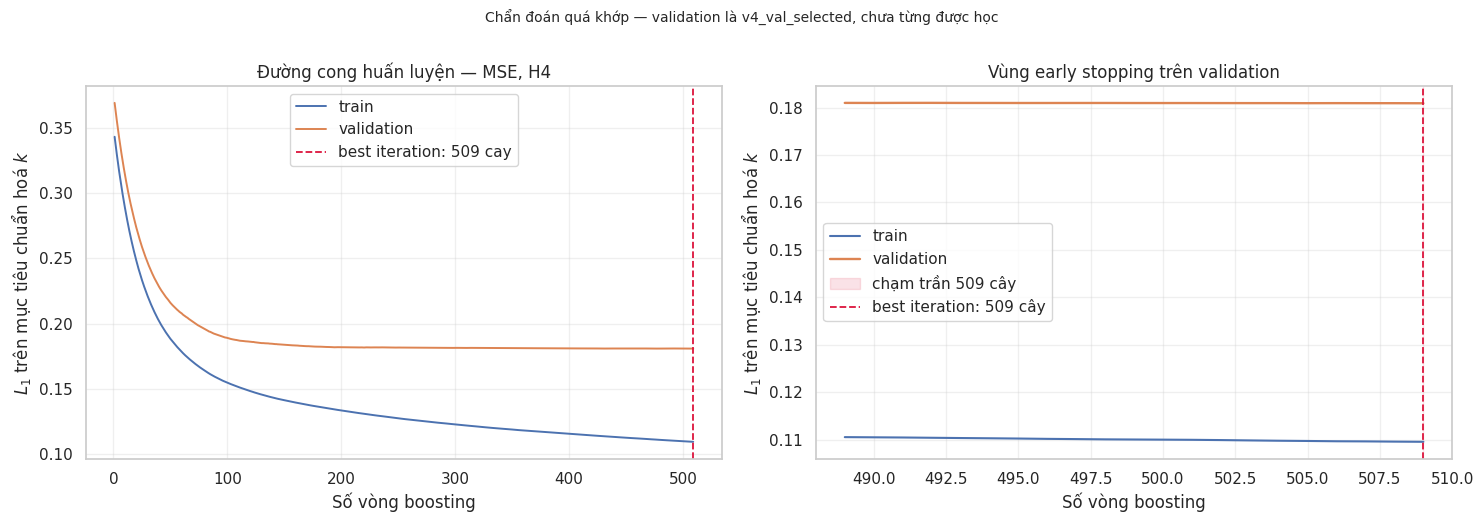


Giu nguyen 509 cay.


,so_cay,wape_train,wape_val,trong_vung_dung_som
0,509,16.725934,27.338083,True


In [25]:
# === DUONG CONG HUAN LUYEN ===
# Fit rieng mot ban co eval_set de lay evals_result_ (ban `model` o cell tren fit khong
# co eval_set nen khong co duong cong). Ban nay CHI dung de ve, khong thay the model.
import matplotlib.pyplot as plt

BUOC_DO_DUONG_CONG = 50          # do WAPE that moi bao nhieu cay
SO_CAY_DUONG_CONG = int(BEST_PARAMS.get('n_estimators', 685))

_p_dc = {k: v for k, v in BEST_PARAMS.items()
         if k not in ('device', 'gpu_platform_id', 'gpu_device_id')}
_p_dc['n_estimators'] = SO_CAY_DUONG_CONG

_Xva_dc = val_h[FEATURES].fillna(MEDIANS).astype(DTYPE)
_yva_dc = val_h['k_target'].astype(DTYPE)

_lich_su = {}
_m_dc = lgb.LGBMRegressor(**_p_dc)
_m_dc.fit(X_dev, y_dev, sample_weight=w_dev,
          eval_set=[(X_dev, y_dev), (_Xva_dc, _yva_dc)],
          eval_names=['train', 'val'], eval_metric='l1',
          callbacks=[lgb.record_evaluation(_lich_su),
                     early_stopping(EARLY_STOPPING_ROUNDS, first_metric_only=True, verbose=True),
                     lgb.log_evaluation(period=200)])
SO_CAY_DUONG_CONG = int(_m_dc.best_iteration_)
# WAPE chi tinh mot moc de tom tat; do thi dung loss theo tung vong de thay early stopping.
BUOC_DO_DUONG_CONG = SO_CAY_DUONG_CONG


def _wape_tai(khung, X, mask, so_cay):
    """WAPE that (kWh) khi chi dung `so_cay` cay dau tien."""
    _k = cat_k(_m_dc.predict(X, num_iteration=so_cay))
    _se = khung['sin_elevation'].to_numpy()
    _yp = np.minimum(_k * mau_chuan_hoa(khung),
                     khung['tran_cong_suat'].to_numpy() * 1.02)
    _yp = np.where(_se <= EPS_ELEV, 0.0, _yp)
    _yt = khung['y_true'].to_numpy()
    return float(np.nansum(np.abs(_yt[mask] - _yp[mask]))
                 / np.nansum(np.abs(_yt[mask])) * 100)


# Mask pham vi cong bo: xet NHAN tai T+h, khong phai cot tai T
def _mask_cong_bo(khung):
    _n = _cot_loc(khung, 'energy_source')
    _d = _cot_loc(khung, 'is_daylight')
    _m = (_n == 'measured').to_numpy() if _n is not None else np.ones(len(khung), bool)
    if _d is not None:
        _m = _m & _d.fillna(False).astype(bool).to_numpy()
    return _m


_dev_dc = dev_h.loc[X_dev.index]
_m_tr = _mask_cong_bo(_dev_dc)
_m_va = _mask_cong_bo(val_h)

_moc = list(range(BUOC_DO_DUONG_CONG, SO_CAY_DUONG_CONG + 1, BUOC_DO_DUONG_CONG))
_w_tr = [_wape_tai(_dev_dc, X_dev, _m_tr, i) for i in _moc]
_w_va = [_wape_tai(val_h, _Xva_dc, _m_va, i) for i in _moc]
_i_tot = int(np.argmin(_w_va))
_w_min = _w_va[_i_tot]

# VUNG BINH NGUYEN: moi moc co WAPE val nam trong nguong tuong doi so voi diem thap nhat.
# Them cay ngoai vung nay khong cai thien co y nghia, chi lam mo hinh nang va de qua khop.
DUNG_NGUONG = 0.001                      # 0,1% tuong doi
_trong_vung = [j for j, w in enumerate(_w_va) if w <= _w_min * (1 + DUNG_NGUONG)]
_j_dau, _j_cuoi = _trong_vung[0], _trong_vung[-1]
SO_CAY_KHUYEN_NGHI = _moc[_j_dau]        # nho nhat ma van dat -> re nhat, it qua khop nhat

print(f"WAPE val thap nhat  : {_w_min:.4f}% tai {_moc[_i_tot]} cay "
      f"(train cung moc {_w_tr[_i_tot]:.4f}%)")
print(f"Vung binh nguyen    : {_moc[_j_dau]} - {_moc[_j_cuoi]} cay "
      f"(WAPE val trong {DUNG_NGUONG*100:.1f}% so voi diem thap nhat)")
print(f"So cay khuyen nghi  : {SO_CAY_KHUYEN_NGHI}")
print(f"Dang dung           : {SO_CAY_DUONG_CONG} cay -> "
      f"{'DU, nen giam' if SO_CAY_KHUYEN_NGHI < SO_CAY_DUONG_CONG * 0.9 else 'hop ly'}")
print(f"Khoang cach train-val tai diem thap nhat: "
      f"{_w_va[_i_tot] - _w_tr[_i_tot]:+.4f} diem")

_fig, _ax = plt.subplots(1, 2, figsize=(15, 5.2))
_l_tr, _l_va = _lich_su['train']['l1'], _lich_su['val']['l1']
_x = np.arange(1, len(_l_tr) + 1)
_ax[0].plot(_x, _l_tr, lw=1.4, label='train')
_ax[0].plot(_x, _l_va, lw=1.4, label='validation')
_ax[0].set_xlabel('Số vòng boosting')
_ax[0].set_ylabel('$L_1$ trên mục tiêu chuẩn hoá $k$')
_ax[0].set_title(f'Đường cong huấn luyện — {LOSS_NAME.upper()}, H{HORIZON_STEPS}')
_ax[0].axvline(_m_dc.best_iteration_, ls='--', c='crimson', lw=1.3,
               label=f'best iteration: {_m_dc.best_iteration_} cay')
_ax[0].legend(); _ax[0].grid(alpha=.3)

_best, _end = int(_m_dc.best_iteration_), len(_l_va)
_start = max(1, _best - 20)
_x_zoom = np.arange(_start, _end + 1)
_ax[1].plot(_x_zoom, _l_tr[_start - 1:_end], lw=1.5, label='train')
_ax[1].plot(_x_zoom, _l_va[_start - 1:_end], lw=1.7, label='validation')
_span_label = (f'{_end - _best} vòng xác nhận không cải thiện'
               if _end >= _best + EARLY_STOPPING_ROUNDS
               else f'chạm trần {SO_CAY_DUONG_CONG} cây')
_ax[1].axvspan(_best, _end, color='crimson', alpha=.12, label=_span_label)
_ax[1].axvline(_best, ls='--', c='crimson', lw=1.3,
               label=f'best iteration: {_best} cây')
_ax[1].set_xlabel('Số vòng boosting')
_ax[1].set_ylabel('$L_1$ trên mục tiêu chuẩn hoá $k$')
_ax[1].set_title('Vùng early stopping trên validation')
_ax[1].legend(); _ax[1].grid(alpha=.3)
_fig.suptitle('Chẩn đoán quá khớp — validation là v4_val_selected, chưa từng được học',
              y=1.0, fontsize=10)
plt.tight_layout(); plt.show()

# ── Train lai mo hinh cuoi o so cay khuyen nghi ──
# Dat False neu muon giu nguyen so cay cua Optuna.
DUNG_SO_CAY_KHUYEN_NGHI = False  # early stopping da chon best_iteration_ tu validation

if DUNG_SO_CAY_KHUYEN_NGHI and SO_CAY_KHUYEN_NGHI < SO_CAY_DUONG_CONG:
    print(f"\nTrain lai mo hinh cuoi voi {SO_CAY_KHUYEN_NGHI} cay "
          f"(thay vi {SO_CAY_DUONG_CONG})...")
    BEST_PARAMS = {**BEST_PARAMS, 'n_estimators': SO_CAY_KHUYEN_NGHI}
    model = fit_an_toan(BEST_PARAMS, X_dev, y_dev, w_dev)

    # Du bao lai tren val de moi bang metric phia sau dung mo hinh moi
    _k2 = cat_k(model.predict(val_h[FEATURES].fillna(MEDIANS).astype(np.float32)))
    val_h['y_pred'] = np.minimum(_k2 * mau_chuan_hoa(val_h),
                                 val_h['tran_cong_suat'].to_numpy() * 1.02)
    val_h.loc[val_h['sin_elevation'] <= EPS_ELEV, 'y_pred'] = 0.0
    _m2 = metrics_3_pham_vi(val_h)['measured_daylight']
    print(f"WAPE val sau khi giam so cay: {_m2['wape']:.4f}%  (n={_m2['n']:,})")
    print("BEST_PARAMS da cap nhat -> cac cell export phia sau se ghi so cay moi.")
else:
    print(f"\nGiu nguyen {SO_CAY_DUONG_CONG} cay.")

pd.DataFrame({'so_cay': _moc, 'wape_train': _w_tr, 'wape_val': _w_va,
              'trong_vung_dung_som': [j in _trong_vung for j in range(len(_moc))]}).head(12)


In [26]:
# ── Kiem chung tre pha + metric cho H4 (dung lai quet_do_tre/metrics_3_pham_vi) ──
_quet = quet_do_tre(val_h)
_k_tot = min(_quet, key=_quet.get)
print("--- QUET DO TRE H4 - TOAN BO 42 TRAM (SAU KHI LOAI SITE 19/24) ---")
for k, v in _quet.items():
    danh_dau = '  <== nho nhat' if k == _k_tot else ''
    print(f"   k={k} ({k * 15:>2} phut truoc): RMSE {v:.4f}{danh_dau}")
print(f"\nKet luan H4: {'KHONG TRE PHA' if _k_tot == 0 else f'TRE {_k_tot} BUOC = {_k_tot * 15} PHUT'}")

_rows = []
for _s, _z in val_h[val_h['is_daylight'].fillna(False).astype(bool)].groupby(SITE_COL):
    _z = _z.sort_values(TIMESTAMP_COL)
    _r = {}
    for k in range(0, 3):
        _yt = _z['y_true'].shift(k)
        _m = _yt.notna()
        _r[k] = float(np.sqrt(np.mean((_z['y_pred'][_m] - _yt[_m]) ** 2)))
    _rows.append({'site_id': _s, 'k_tot_nhat': min(_r, key=_r.get)})
df_tre = pd.DataFrame(_rows)
print(f"So tram khong tre (k=0): {(df_tre['k_tot_nhat'] == 0).sum()}/{len(df_tre)}")

_m = metrics_3_pham_vi(val_h)
_bang = pd.DataFrame(_m).T[['n', 'wape', 'rmse', 'mae', 'r2']].round(4)
print("\n--- METRIC H4 TREN TAP TEST (measured_daylight la con so chinh thuc) ---")
display(_bang)


--- QUET DO TRE H4 - TOAN BO 42 TRAM (SAU KHI LOAI SITE 19/24) ---
   k=0 ( 0 phut truoc): RMSE 4.3050
   k=1 (15 phut truoc): RMSE 4.2439  <== nho nhat
   k=2 (30 phut truoc): RMSE 4.3971
   k=3 (45 phut truoc): RMSE 4.7095

Ket luan H4: TRE 1 BUOC = 15 PHUT
So tram khong tre (k=0): 5/40

--- METRIC H4 TREN TAP TEST (measured_daylight la con so chinh thuc) ---


,n,wape,rmse,mae,r2
all,272569.0,27.3381,4.2851,1.9601,0.8674
measured,272569.0,27.3381,4.2851,1.9601,0.8674
measured_daylight,272569.0,27.3381,4.2851,1.9601,0.8674


In [27]:
# ── Export H4 - dung dung cau truc file nhu H1 (ten file tu dong doi theo HORIZON_STEPS) ──

with open(f'{OUTPUT_DIR}/model_h{HORIZON_STEPS}.pkl', 'wb') as f:
    pickle.dump({'model': model, 'features': FEATURES, 'medians': MEDIANS.to_dict(),
                 'eps_elev': EPS_ELEV, 'clip_k': lay_clip(), 'horizon_steps': HORIZON_STEPS,
                 'loss': LOSS_NAME, 'chuan_hoa': True}, f)

df_tre.to_csv(f'{OUTPUT_DIR}/tre_pha_theo_tram.csv', index=False)
_bang.to_csv(f'{OUTPUT_DIR}/metrics.csv')
with open(f'{OUTPUT_DIR}/ket_qua.json', 'w', encoding='utf-8') as f:
    json.dump({'loss': LOSS_NAME, 'horizon_steps': HORIZON_STEPS,
               'so_dac_trung': len(FEATURES), 'features': FEATURES,
               'best_params': BEST_PARAMS,
               'quet_do_tre': {str(k): v for k, v in _quet.items()},
               'k_tot_nhat': int(_k_tot),
               'so_tram_khong_tre': int((df_tre['k_tot_nhat'] == 0).sum()),
               'metrics': _m}, f, indent=2, ensure_ascii=False, default=str)

TRAIN_COMPAT_DIR = f'../../data/model/v4/06_train/{LOSS_NAME}/h{HORIZON_STEPS}'
os.makedirs(TRAIN_COMPAT_DIR, exist_ok=True)
with open(f'{TRAIN_COMPAT_DIR}/model.pkl', 'wb') as f:
    pickle.dump(model, f)
with open(f'{TRAIN_COMPAT_DIR}/model_config.json', 'w', encoding='utf-8') as f:
    json.dump({
        'horizon_steps': int(HORIZON_STEPS), 'loss_name': LOSS_NAME, 'feature_set_name': '',
        'lgb_objective': LGB_OBJECTIVE, 'features': FEATURES,
        'feature_medians': {k: float(v) for k, v in MEDIANS.items()},
        'train_rows': int(len(X_dev)), 'chuan_hoa': True,
        'cot_quy_mo': 'site_scale', 'cot_sin_elev': 'sin_elevation', 'cot_tran': 'tran_cong_suat',
        'eps_elev': float(EPS_ELEV),
                    'clip_k': float(lay_clip()),
                    'mau_so': MAU_SO,
        'model_params': {k: v for k, v in BEST_PARAMS.items()
                         if k not in ('device', 'gpu_platform_id', 'gpu_device_id')},
    }, f, indent=2, ensure_ascii=False)


# FIX (chong ro ri): metrics_val.json de notebook 07 quet va chon mo hinh vo dich BAT BUOC
# phai tinh tren tap VALIDATION that, khong duoc dung _m (dang tinh tren val_h). Truoc day
# file nay bi ghi nham tu _m (tap test) khien viec chon MAE/Huber/MSE "thay truoc" tap test.
# Tap VAL that - tach biet hoan toan voi tap hoc (mo hinh chi hoc v4_train_selected).
val_h = doc_val_that()
_k_pred_val = cat_k(model.predict(val_h[FEATURES].fillna(MEDIANS).astype(np.float32)))
val_h['y_pred'] = np.minimum(_k_pred_val * mau_chuan_hoa(val_h), val_h['tran_cong_suat'].to_numpy() * 1.02)
val_h.loc[val_h['sin_elevation'] <= EPS_ELEV, 'y_pred'] = 0.0
_m_val = metrics_3_pham_vi(val_h)
print(f"--- METRIC TREN TAP VALIDATION THAT ({len(val_h):,} dong, dung de chon mo hinh) ---")
display(pd.DataFrame(_m_val).T[['n', 'wape', 'rmse', 'mae', 'r2']].round(4))

_val_scope_h4 = _m_val.get('measured_daylight', _m_val.get('measured', _m_val['all']))
with open(f'{TRAIN_COMPAT_DIR}/metrics_val.json', 'w', encoding='utf-8') as f:
    json.dump({'horizon_steps': int(HORIZON_STEPS), 'loss_name': LOSS_NAME,
               'feature_set_name': '', 'measured_daylight': _val_scope_h4,
               'all': _m_val['all']}, f, indent=2, ensure_ascii=False, default=str)


# X_test_h4.parquet - dong bo voi 06_1, tranh loi so cot khong khop khi 07 doc
_cot_xuat_h4 = list(dict.fromkeys(
    FEATURES + [SITE_COL, TIMESTAMP_COL, 'plot_timestamp', TARGET_COL, 'y_true',
                'energy_source', 'is_daylight', 'site_scale', 'sin_elevation', 'tran']
))
_cot_xuat_h4 = [c for c in _cot_xuat_h4 if c in val_h.columns]

print("--- HOAN TAT H4 ---")
print(f"Thu muc ket qua: {OUTPUT_DIR}")
for _f in sorted(os.listdir(OUTPUT_DIR)):
    print(f"   {_f}")


    Loai [19, 24] (capacity_kw khong dang tin): 702,233 -> 668,714 dong
Lọc v4_val_selected: 723,114 -> 668,714 dòng (50 cột)


--- METRIC TREN TAP VALIDATION THAT (272,569 dong, dung de chon mo hinh) ---


,n,wape,rmse,mae,r2
all,272569.0,27.3381,4.2851,1.9601,0.8674
measured,272569.0,27.3381,4.2851,1.9601,0.8674
measured_daylight,272569.0,27.3381,4.2851,1.9601,0.8674


--- HOAN TAT H4 ---
Thu muc ket qua: ../../data/model/v4/06_3_train_mse_h4
   ket_qua.json
   metrics.csv
   model_h4.pkl
   tre_pha_theo_tram.csv
